# 012. LoRA(Low-Rank Adaptation)

## 1. 概要 / Overview

LoRA(Low-Rank Adaptation、低ランク適応)は、事前学習済みの重みを凍結し、微調整(fine-tuning)で
加える重みの更新量を 2 つの低ランク行列の積に制限することで、学習可能パラメータ数を大幅に減らす
手法である。本トピックでは、008 で事前学習した小型 GPT を Tiny Shakespeare に適応させ、
注意機構の Query・Value 射影に掛けた LoRA が全パラメータ微調整(full fine-tuning)に匹敵する
適応性能を得られるかを検証する。あわせて、その理由が更新量の低ランク構造にあるかを、
同じパラメータ数のランダムな疎な更新との比較と、rank を振ったときの飽和によって検証する。

## 2. 参考論文 / References

1. Hu, E. J., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., Wang, L., Chen, W.,
   "LoRA: Low-Rank Adaptation of Large Language Models", ICLR 2022.
   https://arxiv.org/abs/2106.09685(https://openreview.net/forum?id=nZeVKeeFYf9)
   (本トピックの原典。定式化・$\alpha/r$ スケーリング(第 4.1 節)・適用対象の選択(第 7.1 節))
2. Microsoft, `loralib`(LoRA の公式実装)。https://github.com/microsoft/LoRA
   (`loralib/layers.py`の`Linear.reset_parameters`。$A$・$B$ の初期化の出典)
3. Li, C., Farkhoor, H., Liu, R., Yosinski, J., "Measuring the Intrinsic Dimension of
   Objective Landscapes", ICLR 2018. https://arxiv.org/abs/1804.08838
   (内在次元(intrinsic dimension)の定義)
4. Aghajanyan, A., Gupta, S., Zettlemoyer, L., "Intrinsic Dimensionality Explains the
   Effectiveness of Language Model Fine-Tuning", ACL 2021. https://arxiv.org/abs/2012.13255
   (https://aclanthology.org/2021.acl-long.568/)(事前学習済み言語モデルの微調整の内在次元)
5. Kalajdzievski, D., "A Rank Stabilization Scaling Factor for Fine-Tuning with LoRA", 2023.
   https://arxiv.org/abs/2312.03732(rsLoRA。実験 C の交絡の説明に使う)
6. Biderman, D. et al., "LoRA Learns Less and Forgets Less", TMLR 2024.
   https://arxiv.org/abs/2405.09673(LoRA が全パラメータ微調整に届かない条件)
7. Guo, D., Rush, A. M., Kim, Y., "Parameter-Efficient Transfer Learning with Diff Pruning",
   ACL 2021. https://arxiv.org/abs/2012.07463(https://aclanthology.org/2021.acl-long.378/)
   (疎な差分による微調整。実験 B の対照の位置づけ)
8. Houlsby, N. et al., "Parameter-Efficient Transfer Learning for NLP", ICML 2019.
   https://arxiv.org/abs/1902.00751(Adapter。位置づけの説明のみ)

## 3. 理論 / Theory

### 3.1 動機: 全パラメータ微調整のメモリ内訳

事前学習済みモデルの全パラメータを更新する全パラメータ微調整では、学習中に次の量をすべて
保持する。モデルの全パラメータ数を $P$ とし、すべて単精度浮動小数点(fp32、1 要素 4 バイト)で
持つとする。

| 保持するもの | バイト数 |
|---|---|
| 重み | $4P$ |
| 勾配 | $4P$ |
| AdamW(Loshchilov & Hutter, ICLR 2019)の一次モーメント $m$・二次モーメント $v$ | $8P$ |
| 合計(活性化を除く) | $16P$ |

これに加えて、逆伝播のために保存される活性化のメモリが必要になる。さらに、下流タスクごとに
微調整したモデルを保存すると、タスクの数だけ $P$ 個のパラメータの複製が必要になる。

学習可能なパラメータを $P_{\mathrm{train}} \ll P$ 個に絞れれば、勾配と AdamW の状態は
$P_{\mathrm{train}}$ 個分で済み、活性化を除くメモリは次のように減る。

$$
M_{\mathrm{full}} = 16P, \qquad M_{\mathrm{train}} = 4P + 12 P_{\mathrm{train}}
$$

ここで $M_{\mathrm{full}}$ は全パラメータ微調整、$M_{\mathrm{train}}$ は $P_{\mathrm{train}}$
個のパラメータのみを学習する場合の、活性化を除くメモリ(バイト)である。凍結した重み
($4P$)は順伝播に必要なので減らない。

**活性化のメモリは、一部は減る。** 線形層 $y = W x$ の逆伝播では、入力側への勾配
$\partial \mathcal{L} / \partial x = W^\top (\partial \mathcal{L} / \partial y)$ の計算には $W$ しか
要らない。入力 $x$ が必要になるのは、重みの勾配
$\partial \mathcal{L} / \partial W = (\partial \mathcal{L} / \partial y)\, x^\top$ を計算するときだけである
($\mathcal{L}$ は損失)。したがって、重みを凍結した線形層では、逆伝播のために入力 $x$ を保存して
おく必要がない。一方、SwiGLU・softmax・RMSNorm のような非線形の演算が逆伝播のために保存する
テンソルは減らない。これらは、それより入力側にある学習可能な層へ勾配を届けるために必要であり、
凍結した層であっても逆伝播で通過すること自体は変わらないからである。同じ理由で、凍結した線形層では
重みの勾配を求める行列積 $(\partial \mathcal{L} / \partial y)\, x^\top$ を省けるため、1 ステップの
計算時間も減る。

小型のモデルでは活性化のメモリが支配的になりやすい。[011](011_mixed_precision_training.ipynb)
の実験 G では、系列長 256・バッチサイズ 32 の 1 ステップのピークメモリ(約 2.2 GB)に対し、
重み・勾配・AdamW の状態の合計は約 48 MB だった。本トピックでの実測との対応は 7.6 節で述べる。

### 3.2 内在次元: 微調整に必要な更新は低次元に収まるという仮説

Li et al.(ICLR 2018)[3] は、目的関数の地形の **内在次元(intrinsic dimension)** を次のように
測った。$D$ 次元のパラメータ $\theta \in \mathbb{R}^D$ を、固定したランダム行列
$Q \in \mathbb{R}^{D \times d}$ で張られる $d$ 次元の部分空間の中だけで動かす。

$$
\theta = \theta_0 + Q \phi, \qquad \phi \in \mathbb{R}^d
$$

$\theta_0$ は初期値、$\phi$ が学習する $d$ 次元のベクトルである($Q$ と $\theta_0$ は固定)。
$d$ を増やしていき、制約なしの学習の性能の 90% に初めて達する $d$ を内在次元 $d_{90}$ と呼ぶ。
(原論文は射影行列を $P$ と書くが、本ノートブックでは $P$ をパラメータ数に使うため $Q$ と書く。)

Aghajanyan et al.(ACL 2021)[4] はこの測定を事前学習済み言語モデルの微調整に適用し、
パラメータ数が数億でも、数百〜数千次元の部分空間の中の更新で全パラメータ微調整の 90% の性能に
届くタスクが多いこと、また事前学習が進むほど内在次元が小さくなることを報告した。

Hu et al.(ICLR 2022)[1] はこれを受けて、**微調整による重みの更新量 $\Delta W$ も低い
「内在的な rank(intrinsic rank)」を持つ** という仮説を立て、更新量を最初から低ランク行列の
積に制限する LoRA を提案した。本トピックの実験 A は LoRA が全パラメータ微調整に匹敵するか、
実験 B・C はその理由が低ランク構造にあるかを問う。

### 3.3 定式化

対象とする線形層の事前学習済みの重みを $W_0 \in \mathbb{R}^{d_{\mathrm{out}} \times d_{\mathrm{in}}}$
とする。$d_{\mathrm{in}}$ は入力次元、$d_{\mathrm{out}}$ は出力次元である。LoRA は $W_0$ を凍結し、
順伝播を次のように置き換える。

$$
h = W_0 x + \frac{\alpha}{r} B A x
$$

- $x \in \mathbb{R}^{d_{\mathrm{in}}}$: 層への入力
- $h \in \mathbb{R}^{d_{\mathrm{out}}}$: 層の出力
- $A \in \mathbb{R}^{r \times d_{\mathrm{in}}}$、$B \in \mathbb{R}^{d_{\mathrm{out}} \times r}$: 学習する行列
- $r$: rank。$r \ll \min(d_{\mathrm{in}}, d_{\mathrm{out}})$ とする
- $\alpha$: スケーリング定数(3.5 節)

更新量は $\Delta W = \frac{\alpha}{r} B A$ であり、その rank は高々 $r$ である。

**初期化**: $B = 0$ で初期化する。このため学習開始時は $\Delta W = 0$ となり、出力は
ベースモデルと完全に一致する。$A$ の初期化は公式実装`loralib`[2] に従い、`nn.Linear`の
既定と同じ`kaiming_uniform_(a=sqrt(5))`、すなわち一様分布
$A_{ij} \sim \mathcal{U}(-1/\sqrt{d_{\mathrm{in}}},\ 1/\sqrt{d_{\mathrm{in}}})$ とする。
**原論文本文(第 4.1 節)は「$A$ はランダムなガウス分布で初期化する」と書いており、分布の形が
公式実装と異なる。** 本ノートブックは公式実装に従う。どちらでも $B = 0$ なので、学習開始時に
ベースモデルと一致する性質は変わらない。

**勾配の流れ**: $B = 0$ のとき、損失 $\mathcal{L}$ の $A$ についての勾配は
$\partial \mathcal{L} / \partial A = \frac{\alpha}{r} B^\top (\partial \mathcal{L} / \partial h) x^\top = 0$
であり、最初のステップで更新されるのは $B$ のみである。$B$ が 0 から離れた後に $A$ も動き始める。

**学習可能パラメータ数**: 1 行列あたり

$$
P_{\mathrm{LoRA}} = r (d_{\mathrm{in}} + d_{\mathrm{out}})
$$

であり、全パラメータを更新する場合の $d_{\mathrm{in}} d_{\mathrm{out}}$ に比べて、
$d_{\mathrm{in}} = d_{\mathrm{out}} = d$ なら $2r/d$ 倍になる。

**マージ**: 学習後に

$$
W = W_0 + \frac{\alpha}{r} B A
$$

を計算して重みに書き込めば、推論時は元と同じ 1 回の行列積 $h = W x$ になり、追加の遅延が
生じない。逆に $\frac{\alpha}{r} B A$ を引けば $W_0$ に戻せる(unmerge)ので、1 つの
ベースモデルに複数のタスクの LoRA を差し替えて使える。

```mermaid
flowchart LR
    subgraph train["学習時(並列の 2 経路)"]
        x1["x"] --> W0["W0(凍結)"]
        x1 --> A["A(r x d_in)"]
        A --> B["B(d_out x r、0 で初期化)"]
        B --> S["x alpha / r"]
        W0 --> P1(("+"))
        S --> P1
        P1 --> h1["h"]
    end
    subgraph infer["マージ後の推論(単一経路)"]
        x2["x"] --> W["W = W0 + (alpha / r) B A"]
        W --> h2["h"]
    end
```

### 3.4 アルゴリズム

```text
procedure APPLY_LORA(model, target_names, r, alpha):
    for each parameter p in model: p.requires_grad <- False        # 全パラメータを凍結
    for each linear layer W0 in model whose name is in target_names:
        A <- Uniform(-1/sqrt(d_in), 1/sqrt(d_in)), shape (r, d_in)  # 学習可能
        B <- 0, shape (d_out, r)                                    # 学習可能
        replace W0 by LoRALinear(W0, A, B, scale = alpha / r)

procedure TRAIN(model, data, optimizer over {A, B} only):
    for step = 1 .. T:
        h = W0 x + scale * B (A x)        # W0 は凍結、A・B のみ勾配を持つ
        loss.backward(); clip gradients; optimizer.step()

procedure MERGE(layer):
    W0 <- W0 + scale * B A                # 以降 h = W0 x の 1 回の行列積
```

### 3.5 スケーリング $\alpha / r$ の意図と rsLoRA の指摘

Hu et al. [1](第 4.1 節)は、更新量に $\alpha / r$ を乗じ、$\alpha$ を「最初に試した $r$」に
固定して調整しない。Adam 系の optimizer では $\alpha$ の調整は学習率の調整とほぼ同じ働きを
するため、$r$ を変えても学習率を再調整せずに済むことを意図した設計である。

これに対して Kalajdzievski [5](rsLoRA)は、$\alpha / r$ のもとでは $r$ を大きくするほど
学習中の更新量 $\frac{\alpha}{r} B A$ が $r$ に対して縮み、学習が遅くなるため、大きな $r$ の
利点が打ち消されると指摘した。更新量の大きさが $r$ によらず安定するのは、スケーリング係数を
$\alpha / \sqrt{r}$ にした場合であると導出している。

本トピックでは原論文どおり $\alpha / r$ を使う。rsLoRA の指摘は、rank の飽和を調べる実験 C の
**交絡** として扱う(飽和が観測されても、低ランクで十分だからなのか、大きな $r$ で更新量が
縮むからなのかを実験 C だけでは区別できない)。

### 3.6 適用対象: Query・Value 射影

Hu et al. [1] の第 7.1 節は、学習可能パラメータ数の予算を固定したうえで、注意機構の
Query・Key・Value・出力の射影($W_q$・$W_k$・$W_v$・$W_o$)のどれに LoRA を掛けるかを比べ、
$W_q$ と $W_v$ の両方に掛けるのが最もよいと結論している(1 種類の射影に大きな rank を
割り当てるより、rank を小さくしてでも複数の射影に掛けるほうがよい)。本トピックでもこれに従い、
全層の Query 射影 $W^Q$ と Value 射影 $W^V$ にのみ LoRA を掛ける。

層数を $L$、隠れ次元を $d_{\mathrm{model}}$ とすると($W^Q$・$W^V$ はいずれも
$d_{\mathrm{model}} \times d_{\mathrm{model}}$)、学習可能パラメータ数の合計は

$$
P_{\mathrm{LoRA,total}} = 2L \cdot r (d_{\mathrm{model}} + d_{\mathrm{model}}) = 4 L r d_{\mathrm{model}}
$$

である。

### 3.7 他のパラメータ効率のよい微調整との位置づけ

- **Adapter**(Houlsby et al., ICML 2019 [8]): 各層にボトルネック構造の小さな
  順伝播ネットワーク(Feed-Forward Network)を直列に挿入し、それのみを学習する。直列に
  挿入するため、推論時にも追加の計算が残る。LoRA は並列の経路でありマージできる点が異なる。
- **Diff Pruning**(Guo et al., ACL 2021 [7]): 事前学習済みの重みへの差分を疎なベクトルとして
  学習し、どの要素を更新するか(マスク)自体も $L_0$ ノルムの緩和によって学習する。
  実験 B の対照(ランダムマスク疎微調整)は、差分が疎である点は同じだが、マスクを学習せず
  **ランダムに固定する** 点が異なる。したがって実験 B の対照は Diff Pruning の再現ではなく、
  「パラメータ数を揃え、低ランク構造だけを取り除いた更新」として置く。

### 3.8 LoRA が全パラメータ微調整に届かない可能性

Biderman et al.(TMLR 2024)[6] は、プログラミングと数学のドメインで大規模なデータを使った
継続事前学習・指示チューニングにおいて、LoRA が全パラメータ微調整に大きく劣ることを報告した。
同論文は、全パラメータ微調整が学習する更新量の rank が、典型的な LoRA の設定の rank より
10〜100 倍高いことも示している。事前学習とのドメイン差が大きく、適応に多くの情報を書き込む
必要がある設定では、低ランクの制約が効いてしまう。

本トピックの設定(英語版 Wikipedia で事前学習した小型モデルを、戯曲の台詞という文体・語彙の
大きく異なる Tiny Shakespeare に適応させる)は、モデルが小さく、ドメイン差が大きい。
したがって、LoRA が全パラメータ微調整に届かない結果も十分にありうる。実験 A はその可能性を
排除しない判定基準(3 値判定)で宣言する。

## 4. 実装方針 / Implementation Policy

**`src/`に切り出す(スクラッチ実装)**: `src/layers/lora.py`(本トピックで新規作成)。

- `LoRALinear`: ベース層を合成(composition)で包み、$h = W_0 x + \frac{\alpha}{r} B A x$ を
  計算する。ベース層は`nn.Linear`に限定せず、`forward(x)`と入出力次元を持つ任意の
  モジュールを受け付ける(013 で量子化したベース層に差し替えるため)。スケーリングは
  $\alpha / r$ のみを実装する(rsLoRA の $\alpha / \sqrt{r}$ は実験で使わないため実装しない)。
  `merge()`・`unmerge()`・`delta_weight()`を持ち、マージはベース層が`.weight`を持つ
  場合のみ許可する(持たない場合は`TypeError`を送出する)。
- `apply_lora(model, target_module_names, rank, alpha)`: 対象モジュールを置換し、LoRA 以外の
  全パラメータを凍結する。置換したモジュールの完全修飾名を返す。
- `compute_lora_parameter_count(d_in, d_out, rank)`: 閉形式の学習可能パラメータ数
  $r(d_{\mathrm{in}} + d_{\mathrm{out}})$。

[016](../04_alignment/016_supervised_fine_tuning.ipynb)(SFT)でも使うため、使い方を docstring に明記している。既存の`src/`モジュールは
変更しない(`src/layers/__init__.py`から上記 3 つを公開する行を追加したのみで、既存の
関数・クラスの挙動は変わらない)。`MultiHeadAttention`の Query・Key・Value の射影は
独立した`nn.Linear`(`w_q`・`w_k`・`w_v`)なので、`w_q`・`w_v`をそのまま置換できる。

**ノートブック内に直接書く(012 固有)**:

- 実験 B の対照となるランダムマスク疎微調整層(`RandomMaskSparseLinear`)。
  更新量を長さ $k$ のパラメータベクトルとして持ち、固定したインデックスへ scatter する
  ことで、学習可能パラメータ数が文字どおり $k$ になるようにする。
- 実験の学習・評価ループ。学習そのものは`src/training/trainer.py`の
  `train_language_model()`を再利用し、optimizer は`src/training/optimizer.py`の`AdamW`、
  学習率スケジュールは`src/training/schedule.py`の warmup + cosine を使う(007・008 と同じ部品)。
- 出力例の top-p サンプリングのループ(フィルタは`src/generation/decoding.py`の
  `top_p_filter()`を使う)。

**アップロード方針**: 本トピックで学習する LoRA アダプタ・全パラメータ微調整の重みは、
条件間の比較のためのものであり、後続トピックの入力にも読者が単体で取得する対象にもならない。
保存もアップロードもしない。

## 5. 実装 / Implementation

### 5.1 環境セットアップ(Google Colab)

In [1]:
# 環境セットアップ(Google Colab)
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/kojikojiprg/ai-theories.git
    %cd ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。

Cloning into 'ai-theories'...
remote: Enumerating objects: 949, done.
remote: Counting objects: 100% (447/447), done.
remote: Compressing objects: 100% (296/296), done.
remote: Total 949 (delta 265), reused 287 (delta 150), pack-reused 502 (from 1)
Receiving objects: 100% (949/949), 11.73 MiB | 9.95 MiB/s, done.
Resolving deltas: 100% (521/521), done.
/content/ai-theories
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 29.6 MB/s eta 0:00:00
Using Python 3.13.15 environment at: /usr
Resolved 52 packages in 334ms
Prepared 31 packages in 42.14s
Uninstalled 17 packages in 724ms
Installed 31 packages in 311ms
 - click==8.5.0
 + click==8.4.2
 - cuda-bindings==12.9.7
 + cuda-bindings==13.3.1
 - cuda-pathfinder==1.8.0
 + cuda-pathfinder==1.6.0
 - cuda-toolkit==12.8.1
 + cuda-toolkit==13.0.3.0
 - filelock==3.32.5
 + filelock==3.32.2
 - fonttools==4.64.0
 + fonttools==4.63.0
 - fsspec==2025.12.0
 + fsspec==2026.7.0
 - huggingface-hub==1.29.0
 + huggingface-hub==1.28.0
 - kiwisolver==1.5

In [2]:
import copy
import functools
import hashlib
import json
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from huggingface_hub import hf_hub_download
from torch import nn

from src.data.text import (
    encode_corpus,
    encode_text_to_memmap,
    load_tiny_shakespeare,
    make_evaluation_windows,
)
from src.data.tokenizer import load_bpe_id_tokenizer_from_hub
from src.generation.decoding import top_p_filter
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.lora import LoRALinear, apply_lora, compute_lora_parameter_count
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel
from src.training.optimizer import AdamW
from src.training.schedule import compute_warmup_cosine_learning_rate
from src.training.trainer import evaluate_bits_per_byte, train_language_model
from src.utils.statistics import fit_power_law_exponent
from src.utils.visualization import plot_learning_curves_multi_seed, plot_seed_scatter

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
print(f"torch: {torch.__version__} / device: {device}")

ROOT = Path(".")
CORPUS_CACHE_DIR = ROOT / ".cache" / "tiny_shakespeare"  # 外部取得したコーパス(データ源で命名)
ENCODED_CACHE_DIR = ROOT / ".cache" / "012_encoded"  # 012 の条件で符号化したトークン列

MODEL_REPO_ID = "kojikojiprg/ai-theories-small-gpt-en"
MODEL_REVISION = "main"
TOKENIZER_REPO_ID = "kojikojiprg/ai-theories-tokenizer-en"


def hash_tensor(t: torch.Tensor) -> str:
    # テンソルの内容が条件間・実行前後で同一であることを確認するためのハッシュ。
    return hashlib.sha256(t.detach().cpu().contiguous().numpy().tobytes()).hexdigest()


def sync_device() -> None:
    # 時間計測の直前・直後に、非同期に実行される GPU の処理の完了を待つ。
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


precondition_status: dict[str, bool] = {}  # 前提条件の成否(6.1 節で宣言、各実験の節で記録)

torch: 2.13.0+cu130 / device: cuda


### 5.2 スケールの設定(`SMOKE_TEST`の配線)

水準の定義をこの 1 箇所(`LEVELS`)に集約する。`SMOKE_TEST = True`はローカルでのコード経路の
確認用、`SMOKE_TEST = False`は Google Colab T4 での本番実行用である。モデルは事前学習済みの
ものを使うため縮小しない。スモークテストでは、訓練テキストを先頭の一部に切り詰めることで
ステップ数を縮小する(エポック数 $E$ とステップ数の決め方(6.1 節)は本番と共通なので、
「総学習トークン数 = 訓練トークン数 × $E$」という構造は保たれる)。

縮小の規則:

- **rank の集合は縮小しない**(本番・スモークテストとも $\{1,2,4,8,16,32,64\}$ = 公比 2 の等比)。
  中間の rank(2・4・16・32)を描画用のシード数で学習するコード経路を、スモークテストでも実際に
  通すためである。
- 学習率のグリッドは等比のまま縮小する(本番: 公比 $\sqrt{10}$ の 5 水準、スモークテスト:
  そこから 1 つおきに取った公比 10 の 3 水準)。グリッドを拡張するときの刻みも、それぞれの公比に揃える。
- ステップ数・シード数は全条件で共通の規則で縮小する(判定に使う条件のシード数 > 曲線の描画用の
  中間の rank のシード数、という順序関係を保つ)。
- LoRA と疎微調整の学習可能パラメータ数の一致は、モデルを縮小しないので縮小後もそのまま成り立つ。

較正(6.3 節)は`SMOKE_TEST`に従う水準のステップ数で行う。本番(`SMOKE_TEST = False`)では
本番と同じステップ数で較正することになる。スモークテストでの較正は動作確認のみを目的とする。

In [3]:
SMOKE_TEST = False  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)
_smoke_tag = "[動作確認のみ、結論ではない] " if SMOKE_TEST else ""

# --- 全水準で共通の定数(本番実行前に宣言し、SMOKE_TEST で変えない) ---
EPOCHS = 2  # E: 総学習トークン数 = 訓練トークン数 x E(6.1 節)
TRAIN_RATIO, CALIBRATION_RATIO, EVALUATION_RATIO = 0.90, 0.05, 0.05
BATCH_SIZE = 32  # 008 と同一
WARMUP_RATIO = 0.1  # 007・008 と同一
MIN_LEARNING_RATE_RATIO = 0.01  # 007・008 と同一
WEIGHT_DECAY = 0.0  # 全条件で 0(理由は 6.1 節)
CLIP_QUANTILE = 0.90  # gradient clipping の閾値の決め方(008 と同一、6.3 節)
LORA_TARGET_MODULES = ("w_q", "w_v")  # Query・Value 射影(3.6 節)
LORA_ALPHA = 8.0  # 全 rank 共通。r=8 のとき alpha / r = 1
MAIN_RANK = 8  # 実験 A・B の LoRA の rank、実験 B の疎微調整のパラメータ数の基準
JUDGED_RANKS = (1, 8, 64)  # 実験 C の判定に使う rank
DELTA_A = 0.9  # 実験 A の基準 delta(6.1 節)
PRECONDITION_A1_FACTOR = 10.0  # 前提条件 A1: b0 - b1 >= 10 sigma_b1
PRECONDITION_TRAIN_LOSS_DROP = 0.05  # 前提条件 B1・C1: 訓練損失が 5% 以上低下
TRAIN_LOSS_WINDOWS = 64  # 訓練損失の測定に使う、訓練集合から等間隔に選ぶ窓の数(6.1 節)
EVAL_POINTS = 8  # 評価集合の学習曲線の記録点数の目安(最終ステップは必ず記録する)
LR_GRID_RATIO_EXPONENT_STEP = 0.5  # 学習率 = 10 ** (k * 0.5)(公比 sqrt(10))
MAX_GRID_EXPANSIONS = 4  # 較正でグリッドの端が選ばれたときに拡張する最大回数
BOOTSTRAP_RESAMPLES = 10_000
SESSION_BUDGET_SECONDS = 2 * 60 * 60  # Google Colab 1 セッションの目安予算(006〜011 と同一)

# 学習率のグリッド(k の整数列、学習率 = 10 ** (k / 2))。本番の中央の水準は、予備掃引
# (6.3 節の Markdown に記録)から端にならない位置に置いた。端が選ばれた場合は 6.3 節で自動的に拡張する。
PROD_LR_GRID_K = {
    "full": (-7, -6, -5, -4, -3),  # 3.16e-4 .. 3.16e-2
    "lora": (-5, -4, -3, -2, -1),  # 3.16e-3 .. 3.16e-1
    "sparse": (-4, -3, -2, -1, 0),  # 1e-2 .. 1
}

# --- 水準の定義(この 1 箇所に集約する) ---
LEVELS = {
    "smoke": {
        "TRAIN_TEXT_FRACTION": 0.15,  # 訓練テキストの先頭から使う割合
        "RANKS": (1, 2, 4, 8, 16, 32, 64),  # 本番と同一(縮小しない、公比 2 の等比)
        "LR_GRID_K": {m: g[::2] for m, g in PROD_LR_GRID_K.items()},  # 公比 10 の 3 水準
        "LR_GRID_K_STEP": 2,  # グリッド拡張の刻み(公比 10)
        "NUM_SEEDS_JUDGED": 2,
        "NUM_SEEDS_INTERMEDIATE": 1,
    },
    "prod": {
        "TRAIN_TEXT_FRACTION": 1.0,
        "RANKS": (1, 2, 4, 8, 16, 32, 64),  # 公比 2 の等比
        "LR_GRID_K": dict(PROD_LR_GRID_K),  # 公比 sqrt(10) の 5 水準
        "LR_GRID_K_STEP": 1,
        "NUM_SEEDS_JUDGED": 5,
        "NUM_SEEDS_INTERMEDIATE": 2,
    },
}

CURRENT_LEVEL_NAME = "smoke" if SMOKE_TEST else "prod"
CFG = LEVELS[CURRENT_LEVEL_NAME]
TRAIN_TEXT_FRACTION = CFG["TRAIN_TEXT_FRACTION"]
RANKS = CFG["RANKS"]
LR_GRID_K = CFG["LR_GRID_K"]
LR_GRID_K_STEP = CFG["LR_GRID_K_STEP"]
NUM_SEEDS_JUDGED = CFG["NUM_SEEDS_JUDGED"]
NUM_SEEDS_INTERMEDIATE = CFG["NUM_SEEDS_INTERMEDIATE"]
SEEDS_JUDGED = tuple(range(NUM_SEEDS_JUDGED))
SEEDS_INTERMEDIATE = tuple(range(NUM_SEEDS_INTERMEDIATE))


def learning_rate_from_k(k: int) -> float:
    return 10.0 ** (k * LR_GRID_RATIO_EXPONENT_STEP)


# 縮小規則の確認(5.2 節の Markdown セル)。
assert set(JUDGED_RANKS) <= set(RANKS) and MAIN_RANK in RANKS
_rank_ratios = {RANKS[i + 1] / RANKS[i] for i in range(len(RANKS) - 1)}
assert len(_rank_ratios) == 1, f"rank の集合が等比でない: {RANKS}"
for _m, _g in LR_GRID_K.items():
    assert len({_g[i + 1] - _g[i] for i in range(len(_g) - 1)}) == 1, f"{_m} のグリッドが等比でない"
    assert _g[1] - _g[0] == LR_GRID_K_STEP, "拡張の刻みがグリッドの公比と一致しない"
assert NUM_SEEDS_JUDGED > NUM_SEEDS_INTERMEDIATE >= 1

print(f"SMOKE_TEST={SMOKE_TEST}(現在の水準: {CURRENT_LEVEL_NAME!r})")
print(f"EPOCHS={EPOCHS}, BATCH_SIZE={BATCH_SIZE}, TRAIN_TEXT_FRACTION={TRAIN_TEXT_FRACTION}")
print(f"RANKS={RANKS}, JUDGED_RANKS={JUDGED_RANKS}, MAIN_RANK={MAIN_RANK}, LORA_ALPHA={LORA_ALPHA}")
print(f"NUM_SEEDS_JUDGED={NUM_SEEDS_JUDGED}, NUM_SEEDS_INTERMEDIATE={NUM_SEEDS_INTERMEDIATE}")
for _m, _g in LR_GRID_K.items():
    print(
        f"学習率グリッド[{_m}]: {[f'{learning_rate_from_k(k):.2e}' for k in _g]}"
        f"(拡張の刻み k={LR_GRID_K_STEP})"
    )
print(
    f"WEIGHT_DECAY={WEIGHT_DECAY}, WARMUP_RATIO={WARMUP_RATIO}, "
    f"MIN_LEARNING_RATE_RATIO={MIN_LEARNING_RATE_RATIO}, CLIP_QUANTILE={CLIP_QUANTILE}"
)

SMOKE_TEST=False(現在の水準: 'prod')
EPOCHS=2, BATCH_SIZE=32, TRAIN_TEXT_FRACTION=1.0
RANKS=(1, 2, 4, 8, 16, 32, 64), JUDGED_RANKS=(1, 8, 64), MAIN_RANK=8, LORA_ALPHA=8.0
NUM_SEEDS_JUDGED=5, NUM_SEEDS_INTERMEDIATE=2
学習率グリッド[full]: ['3.16e-04', '1.00e-03', '3.16e-03', '1.00e-02', '3.16e-02'](拡張の刻み k=1)
学習率グリッド[lora]: ['3.16e-03', '1.00e-02', '3.16e-02', '1.00e-01', '3.16e-01'](拡張の刻み k=1)
学習率グリッド[sparse]: ['1.00e-02', '3.16e-02', '1.00e-01', '3.16e-01', '1.00e+00'](拡張の刻み k=1)
WEIGHT_DECAY=0.0, WARMUP_RATIO=0.1, MIN_LEARNING_RATE_RATIO=0.01, CLIP_QUANTILE=0.9


### 5.3 ベースモデル・トークナイザの取得(008 がアップロードしたもの)

ベースモデルは`kojikojiprg/ai-theories-small-gpt-en`の`main`ブランチ、トークナイザは
`kojikojiprg/ai-theories-tokenizer-en`から取得する。モデルの構成(層数・$d_{\mathrm{model}}$・
文脈長など)はノートブックに書き込まず、取得した`config.json`から読む。

In [4]:
tokenizer, _tokenizer_loaded_from_hub = load_bpe_id_tokenizer_from_hub(TOKENIZER_REPO_ID)
assert _tokenizer_loaded_from_hub, "トークナイザを Hugging Face Hub から取得できなかった"

_config_path = hf_hub_download(
    repo_id=MODEL_REPO_ID, filename="config.json", revision=MODEL_REVISION
)
_state_path = hf_hub_download(
    repo_id=MODEL_REPO_ID, filename="model_state.pt", revision=MODEL_REVISION
)
MODEL_CONFIG = json.loads(Path(_config_path).read_text(encoding="utf-8"))
print("MODEL_CONFIG:", json.dumps(MODEL_CONFIG, indent=2))
assert tokenizer.vocab_size == MODEL_CONFIG["vocabulary_size"]
assert MODEL_CONFIG["positional_encoding"] == "rope"
assert MODEL_CONFIG["normalization"] == "rmsnorm" and MODEL_CONFIG["feed_forward"] == "swiglu"

D_MODEL = MODEL_CONFIG["d_model"]
NUM_LAYERS = MODEL_CONFIG["num_layers"]
NUM_HEADS = MODEL_CONFIG["num_heads"]
SWIGLU_D_FF = MODEL_CONFIG["swiglu_d_ff"]
VOCAB_SIZE = MODEL_CONFIG["vocabulary_size"]
SEQUENCE_LENGTH = MODEL_CONFIG["sequence_length"]  # 学習・評価の系列長はモデルの文脈長に揃える


def build_base_model_from_hub() -> GPTLanguageModel:
    d_k = D_MODEL // NUM_HEADS
    model = GPTLanguageModel(
        vocabulary_size=VOCAB_SIZE,
        d_model=D_MODEL,
        num_layers=NUM_LAYERS,
        num_heads=NUM_HEADS,
        d_ff=MODEL_CONFIG["d_ff"],
        max_sequence_length=SEQUENCE_LENGTH,
        positional_transform=RotaryPositionEmbedding(d_k, max_position=SEQUENCE_LENGTH),
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, D_MODEL, SWIGLU_D_FF),
        tie_embeddings=MODEL_CONFIG["tie_embeddings"],
        dropout=MODEL_CONFIG["dropout"],
        norm_first=MODEL_CONFIG["norm_first"],
    )
    model.load_state_dict(torch.load(_state_path, map_location="cpu"))
    return model.eval()


base_model = build_base_model_from_hub().to(device)
for _p in base_model.parameters():
    _p.requires_grad_(False)  # base_model 自体は学習しない(各条件は deepcopy から始める)
BASE_STATE_HASH = hash_tensor(
    torch.cat([p.detach().flatten().cpu() for p in base_model.parameters()])
)

# 各条件は、Hub から読み込み直す代わりに base_model の deepcopy から始める(冗長な再読み込みの排除)。
# deepcopy が読み込み直したモデルと完全に同一であることを確認する(重み共有も保たれること)。
_fresh = build_base_model_from_hub().to(device)
_copied = copy.deepcopy(base_model)
_fresh_state, _copied_state = _fresh.state_dict(), _copied.state_dict()
assert _fresh_state.keys() == _copied_state.keys()
assert all(torch.equal(_fresh_state[k], _copied_state[k]) for k in _fresh_state)
assert _copied.lm_head.weight is _copied.token_embedding.weight  # 重み共有が deepcopy 後も保たれる
del _fresh, _copied, _fresh_state, _copied_state

TOTAL_PARAMETERS = sum(p.numel() for p in base_model.parameters())  # 重み共有は 1 回だけ数える
# 閉形式: V d + L (4 d^2 + 3 d d_ff' + 2 d) + d(埋め込み(出力層と共有)、各層の注意機構の 4 射影・
# SwiGLU の 3 射影・RMSNorm 2 個、最終 RMSNorm。いずれもバイアスなし)
_closed_form_total = (
    VOCAB_SIZE * D_MODEL
    + NUM_LAYERS * (4 * D_MODEL**2 + 3 * D_MODEL * SWIGLU_D_FF + 2 * D_MODEL)
    + D_MODEL
)
assert _closed_form_total == TOTAL_PARAMETERS, (TOTAL_PARAMETERS, _closed_form_total)
print(f"全パラメータ数 P = {TOTAL_PARAMETERS:,}(閉形式と一致)")
print(
    f"L={NUM_LAYERS}, d_model={D_MODEL}, h={NUM_HEADS}, d_ff'(SwiGLU)={SWIGLU_D_FF}, "
    f"V={VOCAB_SIZE}, 文脈長={SEQUENCE_LENGTH}"
)

tokenizer.json:   0%|          | 0.00/661k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/305 [00:00<?, ?B/s]

model_state.pt: reconstructing file:   0%|          |  0.00B / 21.0MB            

model_state.pt: downloading bytes:           |  0.00B            

MODEL_CONFIG: {
  "vocabulary_size": 8192,
  "d_model": 256,
  "num_layers": 4,
  "num_heads": 8,
  "d_ff": 1024,
  "swiglu_d_ff": 683,
  "sequence_length": 256,
  "dropout": 0.0,
  "tie_embeddings": true,
  "positional_encoding": "rope",
  "normalization": "rmsnorm",
  "feed_forward": "swiglu",
  "norm_first": true
}
全パラメータ数 P = 5,246,208(閉形式と一致)
L=4, d_model=256, h=8, d_ff'(SwiGLU)=683, V=8192, 文脈長=256


### 5.4 コーパスの取得・分割・符号化

Tiny Shakespeare を **文字列の段階で** 連続区間に分割する(先頭から訓練 90%・較正用検証 5%・
評価 5%)。学習率の較正は較正用検証集合で行い、判定はすべて評価集合で行う。

符号化したトークン列は`.cache/012_encoded/`に`uint16`の memmap としてキャッシュする
(同一セッション内の再実行で再符号化しない)。キャッシュから読んだトークン列が、キャッシュを
経由せず直接符号化したトークン列と完全に一致することを確認する。

In [5]:
raw_text = load_tiny_shakespeare(CORPUS_CACHE_DIR)
_n_chars = len(raw_text)
_n_calibration = int(_n_chars * CALIBRATION_RATIO)
_n_evaluation = int(_n_chars * EVALUATION_RATIO)
_n_train_full = _n_chars - _n_calibration - _n_evaluation
TRAIN_START, CALIBRATION_START, EVALUATION_START = 0, _n_train_full, _n_train_full + _n_calibration

train_text_full = raw_text[:CALIBRATION_START]
calibration_text = raw_text[CALIBRATION_START:EVALUATION_START]
evaluation_text = raw_text[EVALUATION_START:]
# スモークテストでは訓練テキストの先頭のみを使う(較正用検証・評価の集合は本番と同一)。
train_text = train_text_full[: int(len(train_text_full) * TRAIN_TEXT_FRACTION)]
assert train_text_full + calibration_text + evaluation_text == raw_text
print(f"raw_text: {_n_chars:,} 文字 / {len(raw_text.encode('utf-8')):,} バイト")
print(
    f"訓練: {len(train_text):,} 文字(全体の訓練区間は {len(train_text_full):,} 文字)/ "
    f"較正用検証: {len(calibration_text):,} 文字 / 評価: {len(evaluation_text):,} 文字"
)


def encode_split_with_cache(name: str, text: str) -> torch.Tensor:
    memmap = encode_text_to_memmap(tokenizer, text, ENCODED_CACHE_DIR / f"{name}.u16")
    return torch.from_numpy(np.asarray(memmap, dtype=np.int64))


_t0 = time.time()
train_ids = encode_split_with_cache(f"train_{TRAIN_TEXT_FRACTION}", train_text)
train_ids_full = encode_split_with_cache("train_1.0", train_text_full)
calibration_ids = encode_split_with_cache("calibration", calibration_text)
evaluation_ids = encode_split_with_cache("evaluation", evaluation_text)
print(f"符号化(キャッシュ経由): {time.time() - _t0:.2f}s")

# --- キャッシュの前後で数値が完全に一致すること(キャッシュを経由しない直接の符号化と比較) ---
for _name, _text, _ids in (
    ("train", train_text, train_ids),
    ("train_full", train_text_full, train_ids_full),
    ("calibration", calibration_text, calibration_ids),
    ("evaluation", evaluation_text, evaluation_ids),
):
    _direct = encode_corpus(tokenizer, _text)
    assert torch.equal(_direct, _ids), (
        f"{_name}: キャッシュ経由のトークン列が直接の符号化と一致しない"
    )
    # 可逆であるべき変換(符号化と復号)がラウンドトリップで完全一致すること
    assert tokenizer.decode(_ids.tolist()) == _text, (
        f"{_name}: 符号化 -> 復号のラウンドトリップが一致しない"
    )
print("キャッシュ経由と直接の符号化の完全一致・符号化 -> 復号のラウンドトリップ: OK(4 分割すべて)")

calibration_windows, calibration_mask = make_evaluation_windows(calibration_ids, SEQUENCE_LENGTH)
evaluation_windows, evaluation_mask = make_evaluation_windows(evaluation_ids, SEQUENCE_LENGTH)
calibration_bytes = len(calibration_text.encode("utf-8"))
evaluation_bytes = len(evaluation_text.encode("utf-8"))

# 評価の分母の期待値を、評価ループに渡す変数とは独立に、生テキストと分割位置から直接計算する。
EXPECTED_EVALUATION_BYTES = len(raw_text.encode("utf-8")) - len(
    raw_text[:EVALUATION_START].encode("utf-8")
)
EXPECTED_CALIBRATION_BYTES = len(raw_text[:EVALUATION_START].encode("utf-8")) - len(
    raw_text[:CALIBRATION_START].encode("utf-8")
)
assert (
    evaluation_bytes == EXPECTED_EVALUATION_BYTES
    and calibration_bytes == EXPECTED_CALIBRATION_BYTES
)
EVALUATION_WINDOWS_HASH = hash_tensor(evaluation_windows)
EVALUATION_MASK_HASH = hash_tensor(evaluation_mask)

# 訓練損失の測定用: 訓練集合の非重複窓から、パディングを含まない窓を等間隔に選ぶ(6.1 節)。
_train_windows_all, _train_mask_all = make_evaluation_windows(train_ids, SEQUENCE_LENGTH)
_full_windows = torch.nonzero(_train_mask_all.all(dim=1)).flatten()
_selected = _full_windows[
    torch.linspace(0, len(_full_windows) - 1, min(TRAIN_LOSS_WINDOWS, len(_full_windows)))
    .round()
    .long()
]
train_loss_windows = _train_windows_all[_selected]
print(f"訓練損失の測定窓: {tuple(train_loss_windows.shape)}")

# --- ステップ数(6.1 節): 総学習トークン数 = 訓練トークン数 x E ---
TOKENS_PER_STEP = BATCH_SIZE * SEQUENCE_LENGTH


def steps_for(num_train_tokens: int) -> int:
    return (EPOCHS * num_train_tokens) // TOKENS_PER_STEP


NUM_STEPS = steps_for(len(train_ids))
PROD_NUM_STEPS = steps_for(len(train_ids_full))  # 外挿(6.2 節)の目標値。SMOKE_TEST によらない
WARMUP_STEPS = max(1, round(WARMUP_RATIO * NUM_STEPS))
EVAL_INTERVAL = max(1, NUM_STEPS // EVAL_POINTS)
# 資源制約: 全条件がエポック上限 E を満たす(全条件で同じ NUM_STEPS を使う、6.5 節で再確認)
assert EPOCHS * len(train_ids) >= NUM_STEPS * TOKENS_PER_STEP
print(
    f"訓練トークン数: {len(train_ids):,}(全体 {len(train_ids_full):,})/ 較正用検証: "
    f"{len(calibration_ids):,} / 評価: {len(evaluation_ids):,}"
)
print(
    f"NUM_STEPS={NUM_STEPS}(本番 {PROD_NUM_STEPS})、WARMUP_STEPS={WARMUP_STEPS}、"
    f"EVAL_INTERVAL={EVAL_INTERVAL}、学習トークン数 = {NUM_STEPS * TOKENS_PER_STEP:,} "
    f"<= E x 訓練トークン数 = {EPOCHS * len(train_ids):,}"
)
print(
    f"評価の分母: {evaluation_bytes:,} バイト(評価窓 {tuple(evaluation_windows.shape)})/ "
    f"較正の分母: {calibration_bytes:,} バイト(窓 {tuple(calibration_windows.shape)})"
)

raw_text: 1,115,394 文字 / 1,115,394 バイト
訓練: 1,003,856 文字(全体の訓練区間は 1,003,856 文字)/ 較正用検証: 55,769 文字 / 評価: 55,769 文字
.cache/012_encoded/train_1.0.u16: 360,004 トークンを uint16 memmap として書き出した
[キャッシュ] .cache/012_encoded/train_1.0.u16 を再利用する(360,004 トークン、再符号化しない)
.cache/012_encoded/calibration.u16: 20,781 トークンを uint16 memmap として書き出した
.cache/012_encoded/evaluation.u16: 20,881 トークンを uint16 memmap として書き出した
符号化(キャッシュ経由): 0.94s
キャッシュ経由と直接の符号化の完全一致・符号化 -> 復号のラウンドトリップ: OK(4 分割すべて)
訓練損失の測定窓: (64, 256)
訓練トークン数: 360,004(全体 360,004)/ 較正用検証: 20,781 / 評価: 20,881
NUM_STEPS=87(本番 87)、WARMUP_STEPS=9、EVAL_INTERVAL=10、学習トークン数 = 712,704 <= E x 訓練トークン数 = 720,008
評価の分母: 55,769 バイト(評価窓 (82, 256))/ 較正の分母: 55,769 バイト(窓 (82, 256))


### 5.5 LoRA の不変条件の確認(`src/layers/lora.py`)

- `apply_lora`直後の出力が、ベースモデルの出力と`torch.equal`で完全に一致すること($B = 0$)。
- 学習可能パラメータ数が閉形式 $r(d_{\mathrm{in}} + d_{\mathrm{out}})$ と一致すること。
- マージ前後の出力が fp32 で許容誤差内で一致し、`unmerge()`後に元の重みへ戻ること。許容誤差は、
  マージが直接作用する各 LoRA 層の出力に`atol=1e-5`を課し、モデル全体の logits には、層を重ねる
  ことによる fp32 の丸め誤差の累積を見込んで`atol=1e-4`を課す。
  学習直後の $B = 0$ のままではマージが自明になるため、ここでは $B$ に乱数を入れて確認し、
  学習後のモデルでも 6.5 節で同じ確認を行う。
- `.weight`を持たないベース層ではマージが例外になること。

In [6]:
_probe_tokens = evaluation_windows[:4].to(device)
with torch.no_grad():
    _base_logits = base_model(_probe_tokens)

_lora_probe = copy.deepcopy(base_model)
torch.manual_seed(0)
_replaced = apply_lora(_lora_probe, LORA_TARGET_MODULES, rank=MAIN_RANK, alpha=LORA_ALPHA)
print("置換したモジュール:", _replaced)
assert len(_replaced) == 2 * NUM_LAYERS
with torch.no_grad():
    _lora_logits = _lora_probe(_probe_tokens)
assert torch.equal(_lora_logits, _base_logits), (
    "apply_lora 直後の出力がベースモデルと完全一致しない"
)
print("apply_lora 直後の出力 == ベースモデルの出力(torch.equal): OK")

_trainable = [p for p in _lora_probe.parameters() if p.requires_grad]
_expected_lora_params = sum(
    compute_lora_parameter_count(
        _lora_probe.get_submodule(n).in_features,
        _lora_probe.get_submodule(n).out_features,
        MAIN_RANK,
    )
    for n in _replaced
)
assert (
    sum(p.numel() for p in _trainable)
    == _expected_lora_params
    == 4 * NUM_LAYERS * MAIN_RANK * D_MODEL
)
print(
    f"LoRA(r={MAIN_RANK})の学習可能パラメータ数: {_expected_lora_params:,}"
    f"(閉形式 4 L r d_model と一致、全パラメータ数の {_expected_lora_params / TOTAL_PARAMETERS:.4%})"
)

MERGE_LAYER_ATOL = 1e-5  # 各 LoRA 層の出力(マージが直接作用する量)の許容誤差
MERGE_MODEL_ATOL = 1e-4  # モデル全体の logits の許容誤差(L 層分の fp32 の丸め誤差の累積を見込む)
UNMERGE_WEIGHT_ATOL = 1e-6  # unmerge 後の重みの許容誤差


def check_merge_roundtrip(model: nn.Module, replaced: list[str], tokens: torch.Tensor) -> dict:
    # マージ前後で、各 LoRA 層の出力とモデル全体の logits が許容誤差内で一致し、
    # unmerge 後に元の重みへ戻ることを確認する。最大絶対誤差を返す。
    generator = torch.Generator().manual_seed(0)
    layer_inputs = {
        n: torch.randn(
            4, SEQUENCE_LENGTH, model.get_submodule(n).in_features, generator=generator
        ).to(device)
        for n in replaced
    }
    with torch.no_grad():
        logits_before = model(tokens)
        layer_before = {n: model.get_submodule(n)(layer_inputs[n]) for n in replaced}
        weights_before = {n: model.get_submodule(n).base_layer.weight.clone() for n in replaced}
        for n in replaced:
            model.get_submodule(n).merge()
        layer_after = {n: model.get_submodule(n)(layer_inputs[n]) for n in replaced}
        logits_after = model(tokens)
        for n in replaced:
            torch.testing.assert_close(
                layer_after[n], layer_before[n], atol=MERGE_LAYER_ATOL, rtol=0
            )
        torch.testing.assert_close(logits_after, logits_before, atol=MERGE_MODEL_ATOL, rtol=0)
        for n in replaced:
            model.get_submodule(n).unmerge()
            torch.testing.assert_close(
                model.get_submodule(n).base_layer.weight,
                weights_before[n],
                atol=UNMERGE_WEIGHT_ATOL,
                rtol=0,
            )
            assert not model.get_submodule(n).merged
    return {
        "max_layer_error": max(
            float((layer_after[n] - layer_before[n]).abs().max()) for n in replaced
        ),
        "max_logits_error": float((logits_after - logits_before).abs().max()),
        "logits_changed_from_base": not torch.equal(logits_before, _base_logits),
    }


# B に乱数を入れて、マージが自明(Delta W = 0)にならないようにする
with torch.no_grad():
    for _n in _replaced:
        _lora_probe.get_submodule(_n).lora_b.normal_(0.0, 0.02)
_merge_check = check_merge_roundtrip(_lora_probe, _replaced, _probe_tokens)
assert _merge_check["logits_changed_from_base"]
print(
    f"マージ前後の一致(各層の出力 atol={MERGE_LAYER_ATOL}、logits atol={MERGE_MODEL_ATOL})・"
    f"unmerge 後に元の重みへ戻ること(atol={UNMERGE_WEIGHT_ATOL}): OK {_merge_check}"
)


class _NoWeightLayer(nn.Module):
    in_features, out_features = 4, 4

    def forward(self, x):
        return x


try:
    LoRALinear(_NoWeightLayer(), rank=2, alpha=2.0).merge()
    raise AssertionError(".weight を持たないベース層のマージが例外にならなかった")
except TypeError as _e:
    print(f".weight を持たないベース層のマージは例外になる: OK({_e})")
del _lora_probe

置換したモジュール: ['blocks.0.self_attn.w_q', 'blocks.0.self_attn.w_v', 'blocks.1.self_attn.w_q', 'blocks.1.self_attn.w_v', 'blocks.2.self_attn.w_q', 'blocks.2.self_attn.w_v', 'blocks.3.self_attn.w_q', 'blocks.3.self_attn.w_v']
apply_lora 直後の出力 == ベースモデルの出力(torch.equal): OK
LoRA(r=8)の学習可能パラメータ数: 32,768(閉形式 4 L r d_model と一致、全パラメータ数の 0.6246%)
マージ前後の一致(各層の出力 atol=1e-05、logits atol=0.0001)・unmerge 後に元の重みへ戻ること(atol=1e-06): OK {'max_layer_error': 5.245208740234375e-06, 'max_logits_error': 1.2874603271484375e-05, 'logits_changed_from_base': True}
.weight を持たないベース層のマージは例外になる: OK(マージにはベース層が .weight(Tensor)を持つ必要がある: _NoWeightLayer)


### 5.6 ランダムマスク疎微調整層(実験 B の対照、ノートブック内の実装)

対象の行列 $W_0 \in \mathbb{R}^{d_{\mathrm{out}} \times d_{\mathrm{in}}}$ ごとに、
$d_{\mathrm{out}} d_{\mathrm{in}}$ 個の要素から $k = r(d_{\mathrm{in}} + d_{\mathrm{out}})$ 個
($r = 8$、LoRA と同数)の位置 $\mathcal{I}$ をシードごとに固定の乱数で選ぶ。更新量は長さ $k$ の
ベクトル $\delta \in \mathbb{R}^k$(0 で初期化)として持ち、順伝播では

$$
h = \left(W_0 + \mathrm{scatter}_{\mathcal{I}}(\delta)\right) x
$$

を計算する。$\mathrm{scatter}_{\mathcal{I}}(\delta)$ は、位置 $\mathcal{I}$ に $\delta$ の要素を置き、
それ以外を 0 とした $d_{\mathrm{out}} \times d_{\mathrm{in}}$ の行列である。学習可能パラメータは
$\delta$ のみなので、学習可能パラメータ数は文字どおり $k$ になる(マスクを掛けた密な行列を
学習するのではない)。

In [7]:
class RandomMaskSparseLinear(nn.Module):
    # 固定したランダムな位置のみを更新する疎な微調整層(実験 B の対照)。
    def __init__(self, base_layer: nn.Linear, num_updated: int, generator: torch.Generator) -> None:
        super().__init__()
        self.base_layer = base_layer
        for p in self.base_layer.parameters():
            p.requires_grad_(False)
        numel = base_layer.weight.numel()
        # 位置は CPU の乱数生成器で選ぶ(device によらず同じ位置になる)。
        indices = torch.randperm(numel, generator=generator)[:num_updated].sort().values
        self.register_buffer("indices", indices.to(base_layer.weight.device))
        self.delta = nn.Parameter(torch.zeros(num_updated, device=base_layer.weight.device))

    def delta_weight(self) -> torch.Tensor:
        flat = torch.zeros(
            self.base_layer.weight.numel(), device=self.delta.device, dtype=self.delta.dtype
        )
        return flat.index_add(0, self.indices, self.delta).view_as(self.base_layer.weight)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.linear(x, self.base_layer.weight + self.delta_weight(), self.base_layer.bias)


def apply_random_mask_sparse(
    model: nn.Module, target_module_names, rank: int, seed: int
) -> list[str]:
    # 各対象行列に、LoRA(rank)と同数 k = rank (d_in + d_out) の更新位置を割り当てる。
    generator = torch.Generator().manual_seed(seed)
    targets = set(target_module_names)
    matches = [n for n, m in model.named_modules() if n.rsplit(".", 1)[-1] in targets]
    for p in model.parameters():
        p.requires_grad_(False)
    for name in matches:
        parent_name, _, attr = name.rpartition(".")
        parent = model.get_submodule(parent_name)
        layer = getattr(parent, attr)
        k = compute_lora_parameter_count(layer.in_features, layer.out_features, rank)
        setattr(parent, attr, RandomMaskSparseLinear(layer, k, generator))
    return matches


_sparse_probe = copy.deepcopy(base_model)
_sparse_replaced = apply_random_mask_sparse(_sparse_probe, LORA_TARGET_MODULES, MAIN_RANK, seed=0)
with torch.no_grad():
    assert torch.equal(_sparse_probe(_probe_tokens), _base_logits), (
        "疎微調整層の初期出力がベースと一致しない"
    )
# 学習可能パラメータ数が LoRA(r=8)と行列ごとに完全一致すること
for _n in _sparse_replaced:
    _layer = _sparse_probe.get_submodule(_n)
    assert _layer.delta.numel() == compute_lora_parameter_count(D_MODEL, D_MODEL, MAIN_RANK)
    assert _layer.indices.unique().numel() == _layer.delta.numel()  # 位置の重複がない
assert (
    sum(p.numel() for p in _sparse_probe.parameters() if p.requires_grad) == _expected_lora_params
)
print(
    f"疎微調整: 行列ごとの k = {_sparse_probe.get_submodule(_sparse_replaced[0]).delta.numel():,}"
    f"(密度 {compute_lora_parameter_count(D_MODEL, D_MODEL, MAIN_RANK) / D_MODEL**2:.4%})、"
    f"合計 {_expected_lora_params:,}(LoRA r={MAIN_RANK} と行列ごとに一致)/ 初期出力 == ベース: OK"
)
del _sparse_probe

疎微調整: 行列ごとの k = 4,096(密度 6.2500%)、合計 32,768(LoRA r=8 と行列ごとに一致)/ 初期出力 == ベース: OK


### 5.7 1 条件の学習・評価を行うヘルパー

1 回の学習(1 方式 × 1 シード × 1 学習率)を実行し、判定と診断に必要な量を記録して返す。
モデル自体は(出力例のために残す 2 つを除き)返さず、学習済みの重みは保存しない。

- 学習は`train_language_model()`で行い、評価集合(較正では較正用検証集合)の bits-per-byte を
  `EVAL_INTERVAL`ごとに記録する。最終ステップが記録点に含まれない場合は、学習後に最終ステップの
  値を追加で評価する(判定は最終ステップの値で行う)。
- 訓練損失は、訓練集合から等間隔に選んだ固定の窓(5.4 節)での平均損失(nats / トークン)として、
  学習の前後で同じ関数により測る(6.1 節)。
- 学習後に、凍結したパラメータがすべて学習前(ベースモデル)と bit 単位で一致すること、
  凍結したパラメータの`.grad`が`None`であることを確認する。

In [8]:
def mean_loss_nats(model: nn.Module, windows: torch.Tensor, batch_size: int = 16) -> float:
    # 固定の窓(パディングなし)での平均の次トークン予測損失(nats / トークン)。
    model.eval()
    total, count = 0.0, 0
    with torch.no_grad():
        for start in range(0, windows.size(0), batch_size):
            batch = windows[start : start + batch_size].to(device)
            logits = model(batch)[:, :-1, :]
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)), batch[:, 1:].reshape(-1), reduction="sum"
            )
            total += loss.item()
            count += batch[:, 1:].numel()
    return total / count


BASE_TRAIN_LOSS = mean_loss_nats(base_model, train_loss_windows)  # 学習開始時の訓練損失(全条件共通)
print(f"学習開始時の訓練損失(ベースモデル、固定の訓練窓): {BASE_TRAIN_LOSS:.4f} nats / トークン")

_base_parameter_by_name = dict(base_model.named_parameters())


def _base_name(name: str) -> str:
    # LoRALinear・RandomMaskSparseLinear で包んだ層のパラメータ名を、ベースモデルの名前に戻す。
    return name.replace(".base_layer", "")


def relative_update_norms(model: nn.Module, method: str) -> list[float]:
    # Query・Value の各行列について ||Delta W||_F / ||W_0||_F を返す(層順、Query・Value の順)。
    ratios = []
    for layer_index in range(NUM_LAYERS):
        for attr in LORA_TARGET_MODULES:
            name = f"blocks.{layer_index}.self_attn.{attr}"
            w0 = _base_parameter_by_name[f"{name}.weight"]
            module = model.get_submodule(name)
            if method == "full":
                delta = module.weight.detach() - w0
            else:
                delta = module.delta_weight().detach()
            ratios.append(float(delta.norm() / w0.norm()))
    return ratios


def top_rank_energy(model: nn.Module, rank: int) -> list[float]:
    # 全パラメータ微調整の Delta W について、上位 rank 個の特異値が占めるエネルギー(二乗和)の割合。
    energies = []
    for layer_index in range(NUM_LAYERS):
        for attr in LORA_TARGET_MODULES:
            name = f"blocks.{layer_index}.self_attn.{attr}"
            delta = (
                model.get_submodule(name).weight.detach()
                - _base_parameter_by_name[f"{name}.weight"]
            )
            singular_values = torch.linalg.svdvals(delta.float().cpu())
            energies.append(float((singular_values[:rank] ** 2).sum() / (singular_values**2).sum()))
    return energies


def build_condition_model(method: str, seed: int, rank: int) -> tuple[nn.Module, list[str]]:
    model = copy.deepcopy(base_model)
    if method == "full":
        for p in model.parameters():
            p.requires_grad_(True)
        return model, []
    if method == "lora":
        torch.manual_seed(seed)  # A の初期化
        return model, apply_lora(model, LORA_TARGET_MODULES, rank=rank, alpha=LORA_ALPHA)
    if method == "sparse":
        return model, apply_random_mask_sparse(model, LORA_TARGET_MODULES, MAIN_RANK, seed=seed)
    raise ValueError(f"未知の method: {method!r}")


def run_condition(
    method: str,
    seed: int,
    learning_rate: float,
    clip_threshold: float | None,
    rank: int = MAIN_RANK,
    split: str = "evaluation",
    num_steps: int | None = None,
    keep_model: bool = False,
    measure_diagnostics: bool = True,
    eval_interval: int | None = None,
) -> dict:
    num_steps = NUM_STEPS if num_steps is None else num_steps
    # 既定では学習曲線を EVAL_POINTS 点程度記録する。較正では最終ステップのみ評価する(6.3 節)。
    eval_interval = max(1, num_steps // EVAL_POINTS) if eval_interval is None else eval_interval
    windows, mask, total_bytes = {
        "evaluation": (evaluation_windows, evaluation_mask, evaluation_bytes),
        "calibration": (calibration_windows, calibration_mask, calibration_bytes),
    }[split]
    model, replaced = build_condition_model(method, seed, rank)
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = AdamW(trainable, lr=learning_rate, weight_decay=WEIGHT_DECAY)
    schedule = functools.partial(
        compute_warmup_cosine_learning_rate,
        warmup_steps=max(1, round(WARMUP_RATIO * num_steps)),
        total_steps=num_steps,
        peak_learning_rate=learning_rate,
        min_learning_rate=learning_rate * MIN_LEARNING_RATE_RATIO,
    )
    history = train_language_model(
        model,
        train_ids,
        windows,
        mask,
        total_bytes,
        num_steps=num_steps,
        batch_size=BATCH_SIZE,
        sequence_length=SEQUENCE_LENGTH,
        learning_rate=learning_rate,
        eval_interval=eval_interval,
        device=device,
        seed=seed,
        optimizer=optimizer,
        learning_rate_schedule=schedule,
        gradient_clip_threshold=clip_threshold,
    )
    if not history["eval_step"] or history["eval_step"][-1] != num_steps:
        history["eval_step"].append(num_steps)
        history["eval_bits_per_byte"].append(
            evaluate_bits_per_byte(model, windows, mask, total_bytes, device)
        )

    record = {
        "method": method,
        "seed": seed,
        "rank": rank if method == "lora" else None,
        "learning_rate": learning_rate,
        "clip_threshold": clip_threshold,
        "split": split,
        "num_steps": num_steps,
        "history_length": len(history["step"]),
        "history_keys": sorted(history.keys()),
        "num_trainable_parameters": sum(p.numel() for p in trainable),
        "evaluation_denominator_bytes": total_bytes,
        "evaluation_windows_hash": hash_tensor(windows),
        "eval_step": list(history["eval_step"]),
        "eval_bits_per_byte": list(history["eval_bits_per_byte"]),
        "final_bits_per_byte": history["eval_bits_per_byte"][-1],
        "history_first_train_loss": history["train_loss"][0],
        "history_last_train_loss": history["train_loss"][-1],
        "gradient_norm": list(history["gradient_norm"]),
        "clip_trigger_ratio": float(np.mean(history["gradient_clip_triggered"])),
    }

    # 凍結したパラメータが学習前と bit 単位で一致し、.grad が None であること(全条件で確認)
    frozen_checked = 0
    for name, p in model.named_parameters():
        if p.requires_grad:
            continue
        assert p.grad is None, f"凍結パラメータ {name} の .grad が None でない"
        assert torch.equal(p, _base_parameter_by_name[_base_name(name)]), (
            f"凍結パラメータ {name} が変化した"
        )
        frozen_checked += 1
    record["num_frozen_tensors_checked"] = frozen_checked

    if measure_diagnostics:
        record["initial_train_loss"] = BASE_TRAIN_LOSS
        record["final_train_loss"] = mean_loss_nats(model, train_loss_windows)
        record["relative_update_norms"] = relative_update_norms(model, method)
        if method == "full":
            record["top_rank_energy"] = top_rank_energy(model, MAIN_RANK)
    if keep_model:
        record["_model"] = model
        record["_replaced"] = replaced
    else:
        del model
    return record


def public(record: dict) -> dict:
    # 印字・保存用(モデル本体を除く)
    return {k: v for k, v in record.items() if not k.startswith("_")}


_t0 = time.time()
_smoke_record = run_condition("lora", seed=0, learning_rate=1e-3, clip_threshold=None, num_steps=2)
print(
    f"run_condition の動作確認(LoRA、2 ステップ): {time.time() - _t0:.2f}s, "
    f"final_bits_per_byte={_smoke_record['final_bits_per_byte']:.4f}, "
    f"凍結テンソルの確認数={_smoke_record['num_frozen_tensors_checked']}"
)

学習開始時の訓練損失(ベースモデル、固定の訓練窓): 6.2466 nats / トークン
run_condition の動作確認(LoRA、2 ステップ): 0.75s, final_bits_per_byte=3.3886, 凍結テンソルの確認数=38


## 6. 実験 / Experiments

### 6.1 実験宣言セル: 共通の設定・検証すること・判定基準・前提条件

**この節の内容は本番実行の前に確定させ、結果を見た後に変更しない。**

#### 共通の設定

- **起点**: ベースモデルは`kojikojiprg/ai-theories-small-gpt-en`の`main`ブランチ(008 で事前学習)、
  トークナイザは`kojikojiprg/ai-theories-tokenizer-en`。
- **データ**: Tiny Shakespeare を文字列の段階で連続区間に分割する(訓練 90%・較正用検証 5%・
  評価 5%)。学習率の較正は較正用検証集合で行い、判定はすべて評価集合で行う。
- **指標**: 評価集合の bits-per-byte(`evaluate_bits_per_byte()`、非重複窓)。全条件で
  トークナイザが同一なので、1 トークンあたりの指標で比べても条件間の比較は成り立つが、
  リポジトリ内の他トピックとの一貫性のために bits-per-byte を使う。
- **学習**: 007・008 と同じ部品を使う。AdamW(スクラッチ実装)、warmup(ステップ数の 10%)+
  cosine(最小学習率はピークの 1%)、gradient clipping、fp32。バッチサイズ 32、系列長は
  モデルの文脈長(256)。
- **重み減衰は全条件で 0 とする。** 同じ係数でも、全パラメータ微調整では重みそのものを
  原点へ引き寄せる(事前学習で獲得した重みを壊す方向に働く)のに対し、LoRA では $A$・$B$ を 0 へ、
  つまり更新量 $\Delta W$ を 0 へ(ベースモデルの方向へ)引き寄せる。疎微調整でも更新量 $\delta$ を
  0 へ引き寄せる。方式によって正則化の意味が異なるため、共通の係数を置くと方式間の比較に
  別の違いが混ざる。
- **gradient clipping の閾値**: 008 と同じ決め方をとる。すなわち、方式ごとに、較正(クリッピング
  なし)で採用した学習率の実行における勾配ノルムの 90% 分位点を閾値とする。勾配ノルムは
  学習可能なパラメータのみから計算されるため、方式ごとに尺度が大きく異なる(008 の事前学習での
  閾値の値そのものは、どの方式の勾配ノルムの尺度とも対応しない)。実験 C のすべての rank には、
  学習率と同じく LoRA($r=8$)の閾値を使う。
- **ステップ数**: 全条件で共通。総学習トークン数 = 訓練トークン数 × $E$ で決め、$E = 2$ とする
  ($T = \lfloor E N_{\mathrm{train}} / (B S) \rfloor$、$N_{\mathrm{train}}$ は訓練トークン数、
  $B$ はバッチサイズ、$S$ は系列長)。$T$ は、結果を見る前に宣言した $E = 2$ から計算式で決まる値
  である(本番では $T = 87$)。**したがって実験 A〜C の判定は、$T$ ステップという固定の学習予算の
  もとでの比較であり、各方式が収束した状態での性能の比較ではない。** 方式による学習の速さの違い
  (Biderman et al. 2024 [6] の指摘を含む)は判定に含まれる。これは判定基準の変更ではなく、判定が
  何についての主張かを明確にするための記述である。収束の度合いを見るため、学習曲線の最終区間の傾き
  (実験 A の「介入の直接作用点と対比量の距離」の段落を参照)を診断量として実験 A〜C で併記する。
- **判定の時点**: 最終ステップの評価値で判定する。評価集合での学習曲線を記録し、最良値と
  最終値の差(過学習の程度)を診断量として併記する。
- **学習率の較正**: 方式ごと(全パラメータ微調整・LoRA $r=8$・ランダムマスク疎微調整)に、
  公比 $\sqrt{10}$ の等比 5 水準のグリッドで、**本番と同じステップ数** で行う(シード 0、
  gradient clipping なし)。較正用検証集合の最終 bits-per-byte が最小の水準を採用する。
  **採用条件**: 選ばれた水準がグリッドの端でないこと(内点であること)。端だった場合は、その側に
  同じ公比で 1 水準ずつグリッドを拡張して較正をやり直す(最大 4 回)。実験 C のすべての rank には
  LoRA $r=8$ で較正した学習率を使う(原論文の設計どおり、3.5 節)。
- **シード数**: 判定に使う条件は各 5 シード、中間の rank($r \in \{2, 4, 16, 32\}$)は曲線の描画用で
  判定に使わないため 2 シード。シードは、全パラメータ微調整ではミニバッチの順序、LoRA では
  それに加えて $A$ の初期化、疎微調整ではそれに加えて更新位置の選択を決める。
- **LoRA のハイパーパラメータ**: $\alpha = 8$ で全 rank 共通。$r = 8$ のとき $\alpha / r = 1$ になり、
  原論文の「最初に試した $r$ に $\alpha$ を合わせる」設計に対応する。
- **訓練損失の定義(前提条件 B1・C1、実験 B の診断量)**: 訓練集合の非重複窓から等間隔に選んだ
  64 個の固定の窓での平均損失(nats / トークン)とする。学習開始時の値はベースモデルで、最終値は
  学習後のモデルで、同じ窓・同じ関数で測る。学習ループが記録するミニバッチごとの損失は、
  ステップごとに異なるデータに対する値でありミニバッチ間のばらつきを含むため、前後の比較には
  使わない(参考として記録はする)。

#### 記号と条件の対応

| 記号 | 条件 | シード数 |
|---|---|---|
| $b_0$ | ベースモデル(学習なし) | 1(決定的) |
| $b_1$ | 全パラメータ微調整 | 5 |
| $b_2$ | LoRA($r = 8$、Query・Value) | 5 |
| $b_3$ | ランダムマスク疎微調整(Query・Value、行列ごとに $k = 8(d_{\mathrm{in}} + d_{\mathrm{out}})$ 要素) | 5 |
| $b_r$ | rank $r$ の LoRA($r \in \{1, 2, 4, 8, 16, 32, 64\}$、$b_{r=8}$ は $b_2$ と同一の学習結果) | $r \in \{1, 8, 64\}$ は 5、それ以外は 2 |

$b_i$ は評価集合の最終 bits-per-byte、$\bar{b}_i$ はそのシード平均、$s_i$ はシード間の標本
標準偏差(不偏)、$n_i$ はシード数である。シード平均の標準誤差を
$\sigma_{\bar{b}_i} = s_i / \sqrt{n_i}$ とし、シード間は独立とする。$b_0$ は学習を伴わない決定的な
値なので分散 0 として扱う。

#### 実験 A: 全パラメータ微調整との比較

**検証すること**: Query・Value に LoRA($r=8$)を適用すると、全パラメータ微調整による
bits-per-byte の改善幅の $\delta$ 以上を回復する。

**対比量**: 改善幅の回復率

$$
\rho = \frac{b_0 - \bar{b}_2}{b_0 - \bar{b}_1}
$$

**標準偏差の導出**: $u = b_0 - \bar{b}_2$、$v = b_0 - \bar{b}_1$ とおく。$b_0$ は分散 0 なので
$\sigma_u = \sigma_{\bar{b}_2}$、$\sigma_v = \sigma_{\bar{b}_1}$ であり、$u$ と $v$ は独立な
シード集合から作られるので共分散は 0 である。$\rho = u / v$ にデルタ法(1 次のテイラー展開による
誤差伝播)を適用すると

$$
\sigma_\rho^2 \approx \left(\frac{\partial \rho}{\partial u}\right)^2 \sigma_u^2
+ \left(\frac{\partial \rho}{\partial v}\right)^2 \sigma_v^2
= \frac{\sigma_{\bar{b}_2}^2}{v^2} + \frac{u^2 \sigma_{\bar{b}_1}^2}{v^4}
$$

となる。診断量として、各条件のシードを独立に復元抽出するブートストラップ
(10,000 回)による $\rho$ の 95% 区間も併記する(判定には使わない)。

**判定**: $\delta = 0.9$ として、

- 支持: $\rho - 2\sigma_\rho \ge \delta$
- 反証: $\rho + 2\sigma_\rho < \delta$
- 判定不能: 上記以外

$\delta = 0.9$ は「全パラメータ微調整の改善幅の 9 割を回復すれば匹敵とみなす」という、結果を
見る前に置いた実用上の基準である。統計的に導いた値ではない。

**前提条件 A1**: 分母が確定していること。$b_0 - \bar{b}_1 \ge 10\,\sigma_{\bar{b}_1}$。
LoRA の結果に依存しない量で定義している。分母 $v$ が標準誤差に対して小さいと、$\rho$ が不安定に
なり、デルタ法の近似も成り立たなくなるため。

**介入の直接作用点と対比量の距離**: LoRA が直接制約するのは更新量 $\Delta W$ の rank であり、
bits-per-byte は、その更新量が順伝播と学習の全体を経由して現れる下流の量である。それでも
bits-per-byte を対比量とするのは、検証したい主張そのもの(全パラメータ微調整に匹敵する **適応性能**
が得られるか)が bits-per-byte で定義される量だからである。直接の作用点に近い診断量として、
Query・Value の各行列の $\lVert \Delta W \rVert_F / \lVert W_0 \rVert_F$ を両方式で併記する。
さらに、全パラメータ微調整の $\Delta W$ について、上位 8 個の特異値が占めるエネルギー
(特異値の二乗和)の割合を併記する(全パラメータ微調整の更新量が実際に低ランクに近いかの診断)。
また、判定が固定の学習予算($T$ ステップ)のもとでの比較であることを踏まえ、**学習曲線の最終区間の
傾き** を方式ごと(実験 C では rank ごと)に併記する。評価集合の学習曲線の最後の 2 つの記録点
$T' < T$ について

$$
g = \frac{b(T) - b(T')}{T - T'}
$$

をシードごとに求め、シード平均を印字する。$b(t)$ はステップ $t$ での評価集合の bits-per-byte、$T'$ は
最終ステップの 1 つ前の記録点である。$g$ が負で絶対値が大きいほど、最終ステップの時点でまだ学習が
進んでいた(収束していない)ことを示す。

**本文に明記すること**: 3.8 節のとおり、小規模かつドメイン差が大きい設定では LoRA が全パラメータ
微調整に届かない可能性がある(Biderman et al. 2024 [6])。反証・判定不能はいずれも起こりうる結果である。

#### 実験 B: 同じパラメータ数の対照との比較

**検証すること**: 学習可能パラメータ数を揃えたとき、低ランク構造の更新(LoRA $r=8$)のほうが、
Query・Value の重みからランダムに選んだ要素だけを更新する疎な微調整よりも、評価集合の
bits-per-byte が低い。

**対照**: 各対象行列について、LoRA と同数の $k = r(d_{\mathrm{in}} + d_{\mathrm{out}})$($r = 8$)
要素をシードごとに固定の乱数で選び、更新量を 0 で初期化する(5.6 節)。学習率は疎微調整用に
別途較正する。

**対比量**: $d = \bar{b}_3 - \bar{b}_2$。**標準偏差**: 独立な 2 つのシード平均の差なので
$\sigma_d = \sqrt{\sigma_{\bar{b}_3}^2 + \sigma_{\bar{b}_2}^2}$。

**判定**: 支持は $d > 2\sigma_d$、反証は $d < -2\sigma_d$、それ以外は判定不能。

**前提条件 B1**: 両方式(LoRA $r=8$・疎微調整)の全シードで、最終訓練損失が学習開始時の訓練損失
から 5% 以上低下していること(最終訓練損失 $\le 0.95 \times$ 学習開始時の訓練損失)。最適化が
実際に進んでいることの確認であり、どちらの方式が優れているかという仮説とは独立に定義している。

**介入の直接作用点と対比量の距離**: 介入は更新量のパラメータ化(帰納バイアス)であり、
bits-per-byte は下流の量である。差が生じた場合に、それが汎化の違いによるものか最適化の
しやすさの違いによるものかを切り分けるため、最終訓練損失の差(疎微調整 − LoRA のシード平均)を
診断量として併記する。

#### 実験 C: rank の飽和

**検証すること**: $r \in \{1, 2, 4, 8, 16, 32, 64\}$(公比 2 の等比)で、rank を 1 → 8 に上げた
ときの改善幅が、8 → 64 に上げたときの改善幅より大きい。両区間とも rank を 3 回 2 倍にする区間で
あり、刻み(対数尺度での幅)は揃っている。

**対比量**:

$$
c = \Delta_{\mathrm{low}} - \Delta_{\mathrm{high}}
= (\bar{b}_{r=1} - \bar{b}_{r=8}) - (\bar{b}_{r=8} - \bar{b}_{r=64})
= \bar{b}_{r=1} - 2\bar{b}_{r=8} + \bar{b}_{r=64}
$$

**標準偏差**: 3 つのシード平均は独立なシード集合から作られるので、係数 $(1, -2, 1)$ の
線形結合の分散として

$$
\sigma_c = \sqrt{\sigma_{\bar{b}_{r=1}}^2 + 4\sigma_{\bar{b}_{r=8}}^2 + \sigma_{\bar{b}_{r=64}}^2}
$$

**判定**: 支持は $c > 2\sigma_c$、反証は $c < -2\sigma_c$、それ以外は判定不能。

**前提条件 C1**: 全 rank(中間の rank を含む)の全シードで、最終訓練損失が学習開始時の訓練損失から
5% 以上低下していること。

**交絡の明記**: $\alpha / r$ スケーリングでは $r$ が大きいほど実効的な更新量が縮む
(rsLoRA の指摘、3.5 節)。そのため、飽和が観測されても、それが低ランク性によるもの
(小さい rank で必要な更新を表現しきれている)か、更新量の縮小によるもの(大きい rank が
十分に学習できていない)かを、この実験だけでは区別できない。**支持の判定は「低ランクで十分である」
ことの検証とはみなさない。** 診断量として、rank ごとの
$\lVert \frac{\alpha}{r} B A \rVert_F / \lVert W_0 \rVert_F$(Query・Value の全行列・全シードの平均)を
併記する。

**介入の直接作用点と対比量の距離**: rank が直接作用するのは更新量 $\Delta W$ の表現力(rank の上限)
であり、bits-per-byte は下流の量である。上記の更新量のノルムの比が、直接の作用点に近い診断量である。

#### 効率の測定(判定基準を設けない測定)

- 閉形式の表: 全パラメータ微調整と LoRA $r=8$ の学習可能パラメータ数・勾配のバイト数・
  AdamW 状態のバイト数(3.1 節)。閉形式の値と、実際のパラメータ・勾配・optimizer の状態から
  数えた値の一致をアサーションで確認する。
- 実測の表: CUDA 環境でのみ、`torch.cuda.max_memory_allocated()`による 1 ステップのピークメモリと、
  1 ステップあたりの時間を測る。CUDA でない場合はスキップした旨を印字する。
- 判定基準は設けない。この規模では活性化のメモリが支配的であり(3.1 節・011 の実験 G)、
  学習可能パラメータ数の削減がピークメモリの総量に対しては小さく見えうる。

#### 出力例(定性的な観察)

ベースモデル・全パラメータ微調整・LoRA $r=8$(いずれもシード 0 の学習結果)について、同じ
プロンプトから top-p サンプリング($p = 0.9$、シード固定)で生成した例を並べる。判定基準は設けない。

### 6.2 スケーリングの計測と外挿

本番のデータ量がスモークテストの何倍にもなる重い処理(学習(方式ごと)・評価・符号化)について、
3 点のデータ量で実行時間を実測し、$\log t = \log a + b \log n$ をあてはめてべき指数 $b$ を推定し、
本番のデータ量へ外挿する。学習はステップ数、評価は評価する窓の数、符号化は文字数をデータ量 $n$
とする。外挿値に本番での実行回数を乗じ、Colab 無料枠のセッション時間(2 時間を目安)に対する
余裕を確認する。

学習の計測点は本番のステップ数の 1/4・1/2・1 倍とする(3 点目は本番のステップ数そのものの直接計測に
なる)。ステップ数によらない固定費(モデルの複製・凍結パラメータの確認・訓練損失の測定など)があるため、
小さいステップ数だけで $b$ を推定すると $b < 1$ となり、本番の時間を過小に見積もるからである。
それでも $b < 1$ になる場合があるため、見積もりには外挿値と本番のステップ数での直接計測値の
大きいほうを使う。
学習の計測には、本番の学習と同じ学習曲線の評価(記録点ごとの評価集合の評価)が含まれる。

本番での学習の実行回数: 較正 3 方式 × 5 水準(拡張が起きた場合の予備として方式ごとに 2 水準を
上乗せする。較正は最終ステップのみ評価するので、学習曲線の評価を含む計測値で見積もるのは安全側になる)、
実験 A・B の 3 方式 × 5 シード = 15、実験 C の追加分 $r \in \{1, 64\}$ × 5 シード +
$r \in \{2, 4, 16, 32\}$ × 2 シード = 18。

In [9]:
def time_training(method: str, num_steps: int) -> float:
    sync_device()
    t0 = time.time()
    run_condition(
        method,
        seed=0,
        learning_rate=1e-4,
        clip_threshold=None,
        num_steps=num_steps,
        measure_diagnostics=False,
    )
    sync_device()
    return time.time() - t0


def time_evaluation(num_windows: int) -> float:
    sync_device()
    t0 = time.time()
    evaluate_bits_per_byte(
        base_model,
        evaluation_windows[:num_windows],
        evaluation_mask[:num_windows],
        evaluation_bytes,
        device,
    )
    sync_device()
    return time.time() - t0


def time_encoding(num_chars: int) -> float:
    t0 = time.time()
    encode_corpus(tokenizer, raw_text[:num_chars])
    return time.time() - t0


def fit_and_extrapolate(label: str, sizes: list[int], times: list[float], target: int) -> float:
    fit = fit_power_law_exponent(sizes, times)
    extrapolated = fit.coefficient * target**fit.exponent
    detail = ", ".join(f"n={n}: {t:.2f}s" for n, t in zip(sizes, times, strict=True))
    print(
        f"[{label}] {detail} -> b={fit.exponent:.3f}(標準誤差 {fit.exponent_stderr:.3f}), "
        f"R^2={fit.r_squared:.4f}, n={target} での外挿値 {extrapolated:.2f}s"
    )
    return extrapolated


_t0_scaling = time.time()
time_training("lora", 2)  # 初回の呼び出しに伴うオーバーヘッド(カーネルの準備など)を計測から除く
_train_step_sizes = [PROD_NUM_STEPS // 4, PROD_NUM_STEPS // 2, PROD_NUM_STEPS]
_extrapolated_training = {}
for _method in ("full", "lora", "sparse"):
    _times = [time_training(_method, n) for n in _train_step_sizes]
    _fit_value = fit_and_extrapolate(
        f"学習 {_method}(学習曲線の評価を含む)", _train_step_sizes, _times, PROD_NUM_STEPS
    )
    # 固定費のため b < 1 になりうる。外挿値と本番ステップ数での直接計測値の大きいほうを使う(安全側)。
    _extrapolated_training[_method] = max(_fit_value, _times[-1])

_num_windows_all = evaluation_windows.size(0)
_eval_sizes = [max(1, _num_windows_all // 4), max(2, _num_windows_all // 2), _num_windows_all]
time_evaluation(_eval_sizes[0])  # 同上(初回のオーバーヘッドを除く)
_extrapolated_eval = fit_and_extrapolate(
    "評価(評価集合 1 回分、学習の計測に含まれる)",
    _eval_sizes,
    [time_evaluation(n) for n in _eval_sizes],
    _num_windows_all,
)

_encode_sizes = [len(raw_text) // 8, len(raw_text) // 4, len(raw_text) // 2]
_extrapolated_encoding = fit_and_extrapolate(
    "符号化", _encode_sizes, [time_encoding(n) for n in _encode_sizes], len(raw_text)
)
_t_scaling_measurement = time.time() - _t0_scaling

# --- 本番の実行回数を乗じた合計 ---
_prod_ranks = LEVELS["prod"]["RANKS"]
_prod_seeds_judged = LEVELS["prod"]["NUM_SEEDS_JUDGED"]
_prod_seeds_intermediate = LEVELS["prod"]["NUM_SEEDS_INTERMEDIATE"]
_prod_grid_levels = {
    m: len(g) + 2 for m, g in LEVELS["prod"]["LR_GRID_K"].items()
}  # +2 は拡張の予備
_n_rank_runs_judged = (
    sum(1 for r in _prod_ranks if r in JUDGED_RANKS and r != MAIN_RANK) * _prod_seeds_judged
)
_n_rank_runs_intermediate = (
    sum(1 for r in _prod_ranks if r not in JUDGED_RANKS) * _prod_seeds_intermediate
)

_estimate = {
    "較正(学習)": sum(_extrapolated_training[m] * n for m, n in _prod_grid_levels.items()),
    "実験 A・B(学習)": sum(_extrapolated_training[m] for m in ("full", "lora", "sparse"))
    * _prod_seeds_judged,
    "実験 C の追加分(学習)": _extrapolated_training["lora"]
    * (_n_rank_runs_judged + _n_rank_runs_intermediate),
    "符号化(1 回、キャッシュ後は再符号化しない)": _extrapolated_encoding,
    "スケーリング計測自体(このセルの実測)": _t_scaling_measurement,
}
_total_estimate = sum(_estimate.values())
print()
print(
    f"--- 本番実行の見積もり(PROD_NUM_STEPS={PROD_NUM_STEPS}、実行回数を乗じた値、{device} 基準)---"
)
print(
    f"実行回数: 較正 {_prod_grid_levels}(拡張の予備を含む)、実験 A・B {3 * _prod_seeds_judged}、"
    f"実験 C の追加分 {_n_rank_runs_judged + _n_rank_runs_intermediate}"
)
for _k, _v in _estimate.items():
    print(f"  {_k}: {_v:.1f}s")
print(
    f"合計: {_total_estimate:.1f}s({_total_estimate / 60:.1f} 分)/ セッション予算 "
    f"{SESSION_BUDGET_SECONDS / 60:.0f} 分 / 余裕 {SESSION_BUDGET_SECONDS / _total_estimate:.2f} 倍"
)
if _total_estimate > SESSION_BUDGET_SECONDS:
    print("警告: 見積もりがセッション予算を超える。シード数・rank の集合を見直す必要がある。")
print(f"注記: 上記は実行したデバイス({device})での計測に基づく値である。")

[学習 full(学習曲線の評価を含む)] n=21: 4.42s, n=43: 7.15s, n=87: 13.41s -> b=0.781(標準誤差 0.064), R^2=0.9934, n=87 での外挿値 13.06s
[学習 lora(学習曲線の評価を含む)] n=21: 4.13s, n=43: 6.43s, n=87: 11.84s -> b=0.741(標準誤差 0.071), R^2=0.9910, n=87 での外挿値 11.50s
[学習 sparse(学習曲線の評価を含む)] n=21: 4.06s, n=43: 6.47s, n=87: 11.85s -> b=0.753(標準誤差 0.060), R^2=0.9936, n=87 での外挿値 11.56s
[評価(評価集合 1 回分、学習の計測に含まれる)] n=20: 0.03s, n=41: 0.07s, n=82: 0.14s -> b=1.008(標準誤差 0.024), R^2=0.9995, n=82 での外挿値 0.14s
[符号化] n=139424: 0.02s, n=278848: 0.06s, n=557697: 0.11s -> b=1.067(標準誤差 0.102), R^2=0.9910, n=1115394 での外挿値 0.23s

--- 本番実行の見積もり(PROD_NUM_STEPS=87、実行回数を乗じた値、cuda 基準)---
実行回数: 較正 {'full': 7, 'lora': 7, 'sparse': 7}(拡張の予備を含む)、実験 A・B 15、実験 C の追加分 18
  較正(学習): 259.7s
  実験 A・B(学習): 185.5s
  実験 C の追加分(学習): 213.1s
  符号化(1 回、キャッシュ後は再符号化しない): 0.2s
  スケーリング計測自体(このセルの実測): 70.8s
合計: 729.3s(12.2 分)/ セッション予算 120 分 / 余裕 9.87 倍
注記: 上記は実行したデバイス(cuda)での計測に基づく値である。


### 6.3 学習率の較正と gradient clipping の閾値

方式ごとに、`SMOKE_TEST`に従う水準のステップ数(本番では本番と同じステップ数)・シード 0・
gradient clipping なしで学習率のグリッドを掃引し、較正用検証集合の最終 bits-per-byte が最小の
水準を採用する。採用した水準がグリッドの端なら、同じ公比でその側に 1 水準拡張して掃引を続ける
(6.1 節)。gradient clipping の閾値は、採用した水準の実行の勾配ノルムの 90% 分位点とする。

**グリッドの中央の水準を決めた予備掃引の記録**:

- 本番と同じステップ数(87 ステップ)・シード 0 で、**較正用検証集合のみ** を使ってローカル(MPS)で
  行った。評価集合は使っていない。
- 目的は、各方式のグリッドの中央を端にならない位置に置くことのみである(予備掃引で較正用検証集合の
  bits-per-byte が最小だった水準: 全パラメータ微調整 $10^{-2.5}$、LoRA $10^{-1.5}$、
  疎微調整 $10^{-1}$)。本番の較正は、この節のコードで改めて行う。
- 判定基準(6.1 節)は予備掃引より前に確定しており、予備掃引の後に変更していない。
- 予備掃引の時点で、較正用検証集合での改善幅の回復率(実験 A の $\rho$ と同じ形の量を、較正用検証集合・
  シード 0 の値で計算したもの)がおよそ 0.6 であることを把握していた。これは透明性のための記録であり、
  判定には使わない。

In [10]:
calibration_log: dict[str, dict] = {}
LEARNING_RATE: dict[str, float] = {}
CLIP_THRESHOLD: dict[str, float] = {}
_t0_calibration = time.time()

for _method in ("full", "lora", "sparse"):
    _results: dict[int, dict] = {}
    _grid = list(LR_GRID_K[_method])
    _expansions = 0
    while True:
        for _k in _grid:
            if _k in _results:
                continue
            _t0 = time.time()
            _rec = run_condition(
                _method,
                seed=0,
                learning_rate=learning_rate_from_k(_k),
                clip_threshold=None,
                split="calibration",
                measure_diagnostics=False,
                eval_interval=NUM_STEPS,
            )
            _bits_per_byte = _rec["final_bits_per_byte"]
            _results[_k] = {
                "learning_rate": learning_rate_from_k(_k),
                "final_calibration_bits_per_byte": _bits_per_byte
                if math.isfinite(_bits_per_byte)
                else None,
                "gradient_norm_quantile": float(np.quantile(_rec["gradient_norm"], CLIP_QUANTILE)),
                "elapsed_seconds": time.time() - _t0,
            }
            print(
                f"[{_method}] lr={learning_rate_from_k(_k):.2e}: 較正用検証 bits-per-byte = {_bits_per_byte:.4f}"
                f"({time.time() - _t0:.1f}s)"
            )
        _finite = {
            k: r for k, r in _results.items() if r["final_calibration_bits_per_byte"] is not None
        }
        assert _finite, f"{_method}: 全水準で発散した"
        _best = min(_finite, key=lambda k: _finite[k]["final_calibration_bits_per_byte"])
        _keys = sorted(_results)
        if _keys[0] < _best < _keys[-1]:
            break
        if _expansions >= MAX_GRID_EXPANSIONS:
            break
        _grid.append(_best - LR_GRID_K_STEP if _best == _keys[0] else _best + LR_GRID_K_STEP)
        _expansions += 1
        print(f"[{_method}] 端の水準が選ばれたため、グリッドを拡張する(拡張 {_expansions} 回目)")

    _interior = sorted(_results)[0] < _best < sorted(_results)[-1]
    precondition_status[f"calibration_interior_{_method}"] = _interior
    LEARNING_RATE[_method] = learning_rate_from_k(_best)
    CLIP_THRESHOLD[_method] = _results[_best]["gradient_norm_quantile"]
    calibration_log[_method] = {
        "grid": {f"{learning_rate_from_k(k):.3e}": _results[k] for k in sorted(_results)},
        "chosen_learning_rate": LEARNING_RATE[_method],
        "chosen_is_interior": _interior,
        "num_expansions": _expansions,
        "clip_threshold": CLIP_THRESHOLD[_method],
    }
    print(
        f"[{_method}] 採用: lr={LEARNING_RATE[_method]:.3e}(内点={_interior}、拡張 {_expansions} 回)、"
        f"gradient clipping 閾値={CLIP_THRESHOLD[_method]:.4f}"
    )

# 実験 C のすべての rank は LoRA(r=8)の較正結果を使う(6.1 節)
_t_calibration_total = time.time() - _t0_calibration
print(f"\n較正の合計時間: {_t_calibration_total:.1f}s")
print(
    "較正の採用条件(内点であること):",
    {m: precondition_status[f"calibration_interior_{m}"] for m in ("full", "lora", "sparse")},
)
if not SMOKE_TEST:
    assert all(
        precondition_status[f"calibration_interior_{m}"] for m in ("full", "lora", "sparse")
    ), (
        "拡張の上限まで拡張しても内点にならなかった方式がある。グリッドを見直して較正をやり直すこと。"
    )

[full] lr=3.16e-04: 較正用検証 bits-per-byte = 2.3148(13.4s)
[full] lr=1.00e-03: 較正用検証 bits-per-byte = 2.1481(14.4s)
[full] lr=3.16e-03: 較正用検証 bits-per-byte = 2.0548(14.6s)
[full] lr=1.00e-02: 較正用検証 bits-per-byte = 2.1382(15.3s)
[full] lr=3.16e-02: 較正用検証 bits-per-byte = 2.9292(14.5s)
[full] 採用: lr=3.162e-03(内点=True、拡張 0 回)、gradient clipping 閾値=0.9471
[lora] lr=3.16e-03: 較正用検証 bits-per-byte = 2.7779(11.8s)
[lora] lr=1.00e-02: 較正用検証 bits-per-byte = 2.6410(11.6s)
[lora] lr=3.16e-02: 較正用検証 bits-per-byte = 2.5648(11.7s)
[lora] lr=1.00e-01: 較正用検証 bits-per-byte = 3.3538(11.9s)
[lora] lr=3.16e-01: 較正用検証 bits-per-byte = 3.6256(12.0s)
[lora] 採用: lr=3.162e-02(内点=True、拡張 0 回)、gradient clipping 閾値=0.2861
[sparse] lr=1.00e-02: 較正用検証 bits-per-byte = 2.6999(12.2s)
[sparse] lr=3.16e-02: 較正用検証 bits-per-byte = 2.6183(12.1s)
[sparse] lr=1.00e-01: 較正用検証 bits-per-byte = 2.6004(11.9s)
[sparse] lr=3.16e-01: 較正用検証 bits-per-byte = 2.6967(11.7s)
[sparse] lr=1.00e+00: 較正用検証 bits-per-byte = 3.2072(11.7s)
[sparse] 採用: l

### 6.4 本番の学習: ベースモデル・全パラメータ微調整・LoRA($r=8$)・疎微調整

$b_0$ はベースモデルの評価集合での bits-per-byte(学習を伴わない決定的な値)である。3 方式を
それぞれ判定用のシード数で学習する。出力例(6.11 節)とマージの確認(6.5 節)のため、
全パラメータ微調整と LoRA のシード 0 のモデルのみメモリ上に残す(保存はしない)。

In [11]:
B0 = evaluate_bits_per_byte(
    base_model, evaluation_windows, evaluation_mask, evaluation_bytes, device
)
assert evaluate_bits_per_byte(
    base_model, evaluation_windows, evaluation_mask, evaluation_bytes, device
) == B0, "b0 が決定的でない"
print(f"b0(ベースモデル、評価集合)= {B0:.4f}")

main_records: dict[str, list[dict]] = {"full": [], "lora": [], "sparse": []}
kept_models: dict[str, dict] = {}
_t0_main = time.time()
for _method in ("full", "lora", "sparse"):
    for _seed in SEEDS_JUDGED:
        _t0 = time.time()
        _rec = run_condition(
            _method,
            _seed,
            LEARNING_RATE[_method],
            CLIP_THRESHOLD[_method],
            keep_model=(_seed == 0 and _method in ("full", "lora")),
        )
        if "_model" in _rec:
            kept_models[_method] = {"model": _rec.pop("_model"), "replaced": _rec.pop("_replaced")}
        main_records[_method].append(_rec)
        print(
            f"[{_method}] seed={_seed}: b={_rec['final_bits_per_byte']:.4f}, "
            f"訓練損失 {_rec['initial_train_loss']:.4f} -> {_rec['final_train_loss']:.4f}, "
            f"clipping 発動率={_rec['clip_trigger_ratio']:.2f}({time.time() - _t0:.1f}s)"
        )
print(f"本番の学習(3 方式)の合計時間: {time.time() - _t0_main:.1f}s")

b0(ベースモデル、評価集合)= 3.3928
[full] seed=0: b=2.2618, 訓練損失 6.2466 -> 3.3946, clipping 発動率=0.11(15.7s)
[full] seed=1: b=2.2410, 訓練損失 6.2466 -> 3.3485, clipping 発動率=0.13(15.9s)
[full] seed=2: b=2.2610, 訓練損失 6.2466 -> 3.3213, clipping 発動率=0.10(15.9s)
[full] seed=3: b=2.2377, 訓練損失 6.2466 -> 3.3530, clipping 発動率=0.11(15.7s)
[full] seed=4: b=2.2566, 訓練損失 6.2466 -> 3.3634, clipping 発動率=0.10(15.7s)
[lora] seed=0: b=2.6077, 訓練損失 6.2466 -> 4.6590, clipping 発動率=0.10(13.4s)
[lora] seed=1: b=2.6179, 訓練損失 6.2466 -> 4.6642, clipping 発動率=0.15(13.4s)
[lora] seed=2: b=2.6007, 訓練損失 6.2466 -> 4.6437, clipping 発動率=0.10(13.5s)
[lora] seed=3: b=2.6163, 訓練損失 6.2466 -> 4.6788, clipping 発動率=0.20(13.6s)
[lora] seed=4: b=2.6138, 訓練損失 6.2466 -> 4.6821, clipping 発動率=0.20(13.7s)
[sparse] seed=0: b=2.6396, 訓練損失 6.2466 -> 4.6676, clipping 発動率=0.11(13.3s)
[sparse] seed=1: b=2.6362, 訓練損失 6.2466 -> 4.6555, clipping 発動率=0.13(13.1s)
[sparse] seed=2: b=2.6353, 訓練損失 6.2466 -> 4.6505, clipping 発動率=0.11(13.1s)
[sparse] seed=3: b=2.

### 6.5 実験 C の追加の学習(rank の掃引)

$r = 8$ は 6.4 節の LoRA の学習結果を共有する(同じ条件を再学習しない)。判定に使う $r = 1, 64$ は
判定用のシード数、中間の rank は描画用のシード数で学習する。学習率・gradient clipping の閾値は
すべて LoRA($r=8$)の較正結果を使う。

In [12]:
rank_records: dict[int, list[dict]] = {MAIN_RANK: main_records["lora"]}
_t0_rank = time.time()
for _rank in RANKS:
    if _rank == MAIN_RANK:
        continue
    _seeds = SEEDS_JUDGED if _rank in JUDGED_RANKS else SEEDS_INTERMEDIATE
    rank_records[_rank] = []
    for _seed in _seeds:
        _rec = run_condition(
            "lora", _seed, LEARNING_RATE["lora"], CLIP_THRESHOLD["lora"], rank=_rank
        )
        rank_records[_rank].append(_rec)
        print(
            f"[lora r={_rank}] seed={_seed}: b={_rec['final_bits_per_byte']:.4f}, "
            f"訓練損失 {_rec['initial_train_loss']:.4f} -> {_rec['final_train_loss']:.4f}"
        )
rank_records = dict(sorted(rank_records.items()))
print(f"実験 C の追加の学習の合計時間: {time.time() - _t0_rank:.1f}s")

[lora r=1] seed=0: b=2.7831, 訓練損失 6.2466 -> 5.1255
[lora r=1] seed=1: b=2.7818, 訓練損失 6.2466 -> 5.1312
[lora r=1] seed=2: b=2.7866, 訓練損失 6.2466 -> 5.1315
[lora r=1] seed=3: b=2.7707, 訓練損失 6.2466 -> 5.1257
[lora r=1] seed=4: b=2.7740, 訓練損失 6.2466 -> 5.1243
[lora r=2] seed=0: b=2.7225, 訓練損失 6.2466 -> 4.9551
[lora r=2] seed=1: b=2.7119, 訓練損失 6.2466 -> 4.9465
[lora r=4] seed=0: b=2.6676, 訓練損失 6.2466 -> 4.7945
[lora r=4] seed=1: b=2.6568, 訓練損失 6.2466 -> 4.7919
[lora r=16] seed=0: b=2.5838, 訓練損失 6.2466 -> 4.5894
[lora r=16] seed=1: b=2.5888, 訓練損失 6.2466 -> 4.5714
[lora r=32] seed=0: b=2.5686, 訓練損失 6.2466 -> 4.5340
[lora r=32] seed=1: b=2.5667, 訓練損失 6.2466 -> 4.5155
[lora r=64] seed=0: b=2.5611, 訓練損失 6.2466 -> 4.5130
[lora r=64] seed=1: b=2.5611, 訓練損失 6.2466 -> 4.4923
[lora r=64] seed=2: b=2.5684, 訓練損失 6.2466 -> 4.4860
[lora r=64] seed=3: b=2.5623, 訓練損失 6.2466 -> 4.5048
[lora r=64] seed=4: b=2.5646, 訓練損失 6.2466 -> 4.5023
実験 C の追加の学習の合計時間: 244.8s


### 6.6 不変条件のアサーション

実際に実行した全条件の記録を使って確認する(表として出力するだけでなく、すべて実行時に確認する)。

- 全条件で、評価集合の窓(ハッシュ)・評価の分母(UTF-8 バイト数)・ステップ数・学習履歴の長さが同一。
  分母の期待値は、評価ループとは独立に生テキストと分割位置から計算した値(5.4 節)と照合する。
- 全条件がエポック上限 $E$ を満たす。
- 学習可能パラメータ数が閉形式と一致する(全パラメータ微調整は $P$、LoRA は $4 L r d_{\mathrm{model}}$、
  疎微調整は LoRA $r=8$ と同数)。
- `SMOKE_TEST`の配線: 実際に使われたシード数・rank の集合・記録されたキーが、5.2 節で印字した
  実効水準と一致する。
- ベースモデル自体が学習の前後で変化していない。
- 学習後の LoRA(シード 0)で、マージ前後の出力が一致し、`unmerge()`後に元の重みへ戻る。

In [13]:
_all_records = [r for rs in main_records.values() for r in rs] + [
    r for rank, rs in rank_records.items() if rank != MAIN_RANK for r in rs
]
_expected_keys = sorted(main_records["full"][0]["history_keys"])
for _r in _all_records:
    assert _r["split"] == "evaluation"
    assert _r["evaluation_windows_hash"] == EVALUATION_WINDOWS_HASH, "評価窓が条件間で異なる"
    assert _r["evaluation_denominator_bytes"] == EXPECTED_EVALUATION_BYTES, (
        "評価の分母が期待値と異なる"
    )
    assert _r["num_steps"] == NUM_STEPS and _r["history_length"] == NUM_STEPS, (
        "ステップ数が条件間で異なる"
    )
    assert _r["eval_step"][-1] == NUM_STEPS, "最終ステップの評価値が記録されていない"
    assert _r["history_keys"] == _expected_keys
    assert _r["num_steps"] * TOKENS_PER_STEP <= EPOCHS * len(train_ids), "エポック上限を超えた"
    assert _r["initial_train_loss"] == BASE_TRAIN_LOSS
    if _r["method"] == "full":
        assert _r["num_trainable_parameters"] == TOTAL_PARAMETERS
    elif _r["method"] == "lora":
        assert _r["num_trainable_parameters"] == 4 * NUM_LAYERS * _r["rank"] * D_MODEL
    else:
        assert _r["num_trainable_parameters"] == 4 * NUM_LAYERS * MAIN_RANK * D_MODEL
print(
    f"評価窓・評価の分母({EXPECTED_EVALUATION_BYTES:,} バイト)・ステップ数({NUM_STEPS})・"
    f"エポック上限・学習可能パラメータ数: 全 {len(_all_records)} 条件で OK"
)
assert (
    main_records["sparse"][0]["num_trainable_parameters"]
    == main_records["lora"][0]["num_trainable_parameters"]
)

# --- SMOKE_TEST の配線: 実際に使われた値と実効水準の照合 ---
assert all(len(rs) == NUM_SEEDS_JUDGED for rs in main_records.values())
assert all([r["seed"] for r in rs] == list(SEEDS_JUDGED) for rs in main_records.values())
assert tuple(rank_records) == tuple(RANKS), (tuple(rank_records), RANKS)
for _rank, _rs in rank_records.items():
    _n = NUM_SEEDS_JUDGED if _rank in JUDGED_RANKS else NUM_SEEDS_INTERMEDIATE
    assert len(_rs) == _n and all(r["rank"] == _rank for r in _rs)
    assert all(r["learning_rate"] == LEARNING_RATE["lora"] for r in _rs)
print(
    f"SMOKE_TEST の配線: シード数(判定 {NUM_SEEDS_JUDGED} / 中間 {NUM_SEEDS_INTERMEDIATE})・"
    f"rank の集合 {tuple(rank_records)}・学習率・記録キーが実効水準と一致: OK"
)

# --- ベースモデルが変化していないこと ---
assert (
    hash_tensor(torch.cat([p.detach().flatten().cpu() for p in base_model.parameters()]))
    == BASE_STATE_HASH
)
print("ベースモデルの重みは学習の前後で不変: OK")

# --- 学習後の LoRA でのマージ・アンマージ ---
_trained_merge_check = check_merge_roundtrip(
    kept_models["lora"]["model"], kept_models["lora"]["replaced"], _probe_tokens
)
assert _trained_merge_check["logits_changed_from_base"], (
    "学習後の LoRA の出力がベースと同一(学習されていない)"
)
print(
    f"学習後の LoRA(seed 0): マージ前後の出力の一致・unmerge 後の重みの復元: OK {_trained_merge_check}"
)

評価窓・評価の分母(55,769 バイト)・ステップ数(87)・エポック上限・学習可能パラメータ数: 全 33 条件で OK
SMOKE_TEST の配線: シード数(判定 5 / 中間 2)・rank の集合 (1, 2, 4, 8, 16, 32, 64)・学習率・記録キーが実効水準と一致: OK
ベースモデルの重みは学習の前後で不変: OK
学習後の LoRA(seed 0): マージ前後の出力の一致・unmerge 後の重みの復元: OK {'max_layer_error': 7.152557373046875e-06, 'max_logits_error': 1.811981201171875e-05, 'logits_changed_from_base': True}


### 6.7 実験 A: 全パラメータ微調整との比較

In [15]:
def seed_mean_and_standard_error(
    records: list[dict], key: str = "final_bits_per_byte"
) -> tuple[float, float]:
    values = np.array([r[key] for r in records], dtype=float)
    standard_error = (
        float(values.std(ddof=1) / np.sqrt(len(values))) if len(values) > 1 else float("nan")
    )
    return float(values.mean()), standard_error


def three_way_verdict(value: float, sigma: float) -> str:
    if not (math.isfinite(value) and math.isfinite(sigma)):
        return "判定不能"
    if value > 2 * sigma:
        return "支持"
    if value < -2 * sigma:
        return "反証"
    return "判定不能"


b1_mean, sigma_b1 = seed_mean_and_standard_error(main_records["full"])
b2_mean, sigma_b2 = seed_mean_and_standard_error(main_records["lora"])
b3_mean, sigma_b3 = seed_mean_and_standard_error(main_records["sparse"])
_u, _v = B0 - b2_mean, B0 - b1_mean
rho = _u / _v
sigma_rho = math.sqrt(sigma_b2**2 / _v**2 + _u**2 * sigma_b1**2 / _v**4)

# 前提条件 A1(LoRA の結果に依存しない量で定義)
precondition_status["A1"] = bool(_v >= PRECONDITION_A1_FACTOR * sigma_b1)

if rho - 2 * sigma_rho >= DELTA_A:
    verdict_A = "支持"
elif rho + 2 * sigma_rho < DELTA_A:
    verdict_A = "反証"
else:
    verdict_A = "判定不能"

# 診断量: シードの復元抽出によるブートストラップ区間(判定には使わない)
_rng = np.random.default_rng(0)
_b1_values = np.array([r["final_bits_per_byte"] for r in main_records["full"]])
_b2_values = np.array([r["final_bits_per_byte"] for r in main_records["lora"]])
_boot = []
for _ in range(BOOTSTRAP_RESAMPLES):
    _b1s = _rng.choice(_b1_values, size=len(_b1_values), replace=True).mean()
    _b2s = _rng.choice(_b2_values, size=len(_b2_values), replace=True).mean()
    _boot.append((B0 - _b2s) / (B0 - _b1s))
rho_bootstrap_interval = tuple(float(x) for x in np.percentile(_boot, [2.5, 97.5]))

print(
    f"{_smoke_tag}b0={B0:.4f}, b1={b1_mean:.4f}(標準誤差 {sigma_b1:.4f}), b2={b2_mean:.4f}(標準誤差 {sigma_b2:.4f})"
)
print(
    f"{_smoke_tag}rho={rho:.4f}, sigma_rho={sigma_rho:.4f}, "
    f"[rho - 2 sigma, rho + 2 sigma]=[{rho - 2 * sigma_rho:.4f}, {rho + 2 * sigma_rho:.4f}], delta={DELTA_A}"
)
print(
    f"{_smoke_tag}前提条件 A1(b0 - b1 = {_v:.4f} >= {PRECONDITION_A1_FACTOR:.0f} x {sigma_b1:.4f}): "
    f"{precondition_status['A1']}"
)
print(f"{_smoke_tag}判定関数の結果: {verdict_A}")
print(
    f"{_smoke_tag}診断量: ブートストラップ 95% 区間 = [{rho_bootstrap_interval[0]:.4f}, "
    f"{rho_bootstrap_interval[1]:.4f}]"
)


def mean_over_records(records: list[dict], key: str) -> np.ndarray:
    # 行列ごとの値(層順、Query・Value の順)のシード平均
    return np.mean([r[key] for r in records], axis=0)


for _method in ("full", "lora"):
    _ratios = mean_over_records(main_records[_method], "relative_update_norms")
    print(
        f"{_smoke_tag}診断量 ||Delta W||_F / ||W0||_F [{_method}](層ごとに Query, Value): "
        + ", ".join(f"{x:.4f}" for x in _ratios)
    )
_energy = mean_over_records(main_records["full"], "top_rank_energy")
print(
    f"{_smoke_tag}診断量: 全パラメータ微調整の Delta W の上位 {MAIN_RANK} 特異値のエネルギー割合"
    f"(層ごとに Query, Value): " + ", ".join(f"{x:.4f}" for x in _energy)
)


def final_slope(record: dict) -> float:
    # 評価集合の学習曲線の最後の 2 つの記録点の傾き (b(T) - b(T')) / (T - T')
    steps, values = record["eval_step"], record["eval_bits_per_byte"]
    return (values[-1] - values[-2]) / (steps[-1] - steps[-2])


def mean_final_slope(records: list[dict]) -> float:
    return float(np.mean([final_slope(r) for r in records]))


for _method in ("full", "lora", "sparse"):
    print(
        f"{_smoke_tag}診断量: 学習曲線の最終区間の傾き(シード平均、bits-per-byte / ステップ)"
        f"[{_method}]: {mean_final_slope(main_records[_method]):+.6f}"
    )
for _method in ("full", "lora", "sparse"):
    _gaps = [min(r["eval_bits_per_byte"]) - r["final_bits_per_byte"] for r in main_records[_method]]
    print(
        f"{_smoke_tag}診断量: 最良値 - 最終値(過学習の程度)[{_method}]: "
        + ", ".join(f"{g:+.4f}" for g in _gaps)
    )

b0=3.3928, b1=2.2516(標準誤差 0.0051), b2=2.6113(標準誤差 0.0032)
rho=0.6848, sigma_rho=0.0041, [rho - 2 sigma, rho + 2 sigma]=[0.6766, 0.6931], delta=0.9
前提条件 A1(b0 - b1 = 1.1412 >= 10 x 0.0051): True
判定関数の結果: 反証
診断量: ブートストラップ 95% 区間 = [0.6778, 0.6921]
診断量 ||Delta W||_F / ||W0||_F [full](層ごとに Query, Value): 0.2622, 0.1630, 0.2783, 0.2015, 0.2794, 0.2165, 0.2849, 0.2279
診断量 ||Delta W||_F / ||W0||_F [lora](層ごとに Query, Value): 0.8003, 0.5891, 1.0563, 0.7691, 1.1512, 0.9389, 1.2392, 1.1682
診断量: 全パラメータ微調整の Delta W の上位 8 特異値のエネルギー割合(層ごとに Query, Value): 0.3326, 0.2861, 0.4058, 0.3416, 0.3637, 0.3397, 0.3824, 0.4063
診断量: 学習曲線の最終区間の傾き(シード平均、bits-per-byte / ステップ)[full]: -0.000308
診断量: 学習曲線の最終区間の傾き(シード平均、bits-per-byte / ステップ)[lora]: -0.000178
診断量: 学習曲線の最終区間の傾き(シード平均、bits-per-byte / ステップ)[sparse]: -0.000145
診断量: 最良値 - 最終値(過学習の程度)[full]: +0.0000, +0.0000, +0.0000, +0.0000, +0.0000
診断量: 最良値 - 最終値(過学習の程度)[lora]: +0.0000, +0.0000, +0.0000, +0.0000, +0.0000
診断量: 最良値 - 最終値(過学習の程度)[sparse]: +0.0000, +0.0000, +0

評価集合の学習曲線(方式ごとにシードを重ね描き、ステップ 0 は $b_0$)と、最終 bits-per-byte の
シードごとの散布図を示す。

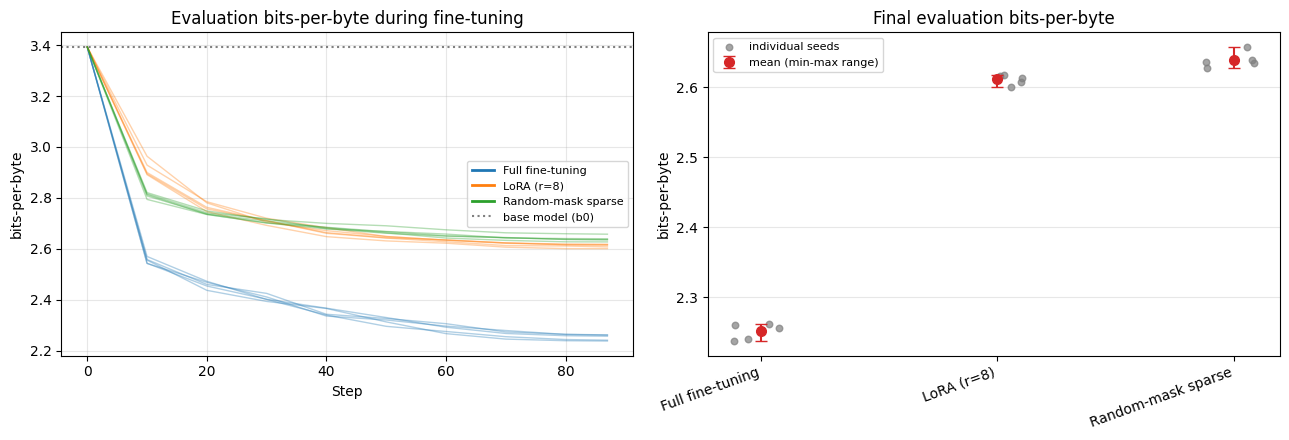

In [16]:
def curve_histories(records: list[dict]) -> list[dict]:
    return [
        {"step": [0] + r["eval_step"], "bits_per_byte": [B0] + r["eval_bits_per_byte"]}
        for r in records
    ]


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
plot_learning_curves_multi_seed(
    {
        "Full fine-tuning": curve_histories(main_records["full"]),
        f"LoRA (r={MAIN_RANK})": curve_histories(main_records["lora"]),
        "Random-mask sparse": curve_histories(main_records["sparse"]),
    },
    step_key="step",
    value_key="bits_per_byte",
    title="Evaluation bits-per-byte during fine-tuning",
    ylabel="bits-per-byte",
    ax=axes[0],
)
axes[0].axhline(B0, color="gray", linestyle=":", label="base model (b0)")
axes[0].legend(fontsize=8)
plot_seed_scatter(
    {
        "Full fine-tuning": [r["final_bits_per_byte"] for r in main_records["full"]],
        f"LoRA (r={MAIN_RANK})": [r["final_bits_per_byte"] for r in main_records["lora"]],
        "Random-mask sparse": [r["final_bits_per_byte"] for r in main_records["sparse"]],
    },
    title="Final evaluation bits-per-byte",
    ylabel="bits-per-byte",
    ax=axes[1],
)
fig.tight_layout()
plt.show()

### 6.8 実験 B: 同じパラメータ数の対照との比較

In [17]:
d_B = b3_mean - b2_mean
sigma_d_B = math.sqrt(sigma_b3**2 + sigma_b2**2)
verdict_B = three_way_verdict(d_B, sigma_d_B)


def train_loss_dropped(records: list[dict]) -> bool:
    return all(
        r["final_train_loss"] <= (1 - PRECONDITION_TRAIN_LOSS_DROP) * r["initial_train_loss"]
        for r in records
    )


precondition_status["B1"] = train_loss_dropped(main_records["lora"]) and train_loss_dropped(
    main_records["sparse"]
)
_final_loss_lora, _ = seed_mean_and_standard_error(main_records["lora"], "final_train_loss")
_final_loss_sparse, _ = seed_mean_and_standard_error(main_records["sparse"], "final_train_loss")

print(
    f"{_smoke_tag}b3={b3_mean:.4f}(標準誤差 {sigma_b3:.4f}), b2={b2_mean:.4f}(標準誤差 {sigma_b2:.4f})"
)
print(
    f"{_smoke_tag}d = b3 - b2 = {d_B:.4f}, sigma_d = {sigma_d_B:.4f}, 2 sigma_d = {2 * sigma_d_B:.4f}"
)
print(
    f"{_smoke_tag}前提条件 B1(両方式の全シードで訓練損失が 5% 以上低下): {precondition_status['B1']}"
)
print(f"{_smoke_tag}判定関数の結果: {verdict_B}")
print(
    f"{_smoke_tag}診断量: 最終訓練損失の差(疎微調整 - LoRA)= {_final_loss_sparse - _final_loss_lora:+.4f} nats"
    f"(疎微調整 {_final_loss_sparse:.4f}、LoRA {_final_loss_lora:.4f})"
)
for _method in ("lora", "sparse"):
    print(
        f"{_smoke_tag}診断量: 学習曲線の最終区間の傾き(シード平均、bits-per-byte / ステップ)"
        f"[{_method}]: {mean_final_slope(main_records[_method]):+.6f}"
    )
_ratios_sparse = mean_over_records(main_records["sparse"], "relative_update_norms")
print(
    f"{_smoke_tag}診断量 ||Delta W||_F / ||W0||_F [sparse]: "
    + ", ".join(f"{x:.4f}" for x in _ratios_sparse)
)

b3=2.6391(標準誤差 0.0050), b2=2.6113(標準誤差 0.0032)
d = b3 - b2 = 0.0279, sigma_d = 0.0059, 2 sigma_d = 0.0119
前提条件 B1(両方式の全シードで訓練損失が 5% 以上低下): True
判定関数の結果: 支持
診断量: 最終訓練損失の差(疎微調整 - LoRA)= -0.0092 nats(疎微調整 4.6563、LoRA 4.6656)
診断量: 学習曲線の最終区間の傾き(シード平均、bits-per-byte / ステップ)[lora]: -0.000178
診断量: 学習曲線の最終区間の傾き(シード平均、bits-per-byte / ステップ)[sparse]: -0.000145
診断量 ||Delta W||_F / ||W0||_F [sparse]: 1.3281, 1.0830, 2.0418, 1.7238, 2.0019, 1.8546, 2.1152, 2.0841


### 6.9 実験 C: rank の飽和

r= 1: b=2.7792(標準誤差 0.0030、5 シード)、診断量 ||(alpha/r) B A||_F / ||W0||_F の平均 = 0.9982、学習曲線の最終区間の傾き(シード平均)= -0.000186
r= 2: b=2.7172(標準誤差 0.0053、2 シード)、診断量 ||(alpha/r) B A||_F / ||W0||_F の平均 = 1.0291、学習曲線の最終区間の傾き(シード平均)= -0.000185
r= 4: b=2.6622(標準誤差 0.0054、2 シード)、診断量 ||(alpha/r) B A||_F / ||W0||_F の平均 = 1.0357、学習曲線の最終区間の傾き(シード平均)= -0.000112
r= 8: b=2.6113(標準誤差 0.0032、5 シード)、診断量 ||(alpha/r) B A||_F / ||W0||_F の平均 = 0.9640、学習曲線の最終区間の傾き(シード平均)= -0.000178
r=16: b=2.5863(標準誤差 0.0025、2 シード)、診断量 ||(alpha/r) B A||_F / ||W0||_F の平均 = 0.9095、学習曲線の最終区間の傾き(シード平均)= -0.000171
r=32: b=2.5677(標準誤差 0.0009、2 シード)、診断量 ||(alpha/r) B A||_F / ||W0||_F の平均 = 0.8685、学習曲線の最終区間の傾き(シード平均)= -0.000204
r=64: b=2.5635(標準誤差 0.0014、5 シード)、診断量 ||(alpha/r) B A||_F / ||W0||_F の平均 = 0.8444、学習曲線の最終区間の傾き(シード平均)= -0.000160
Delta_low = b(r=1) - b(r=8) = 0.1680, Delta_high = b(r=8) - b(r=64) = 0.0478
c = 0.1202, sigma_c = 0.0071, 2 sigma_c = 0.0143
前提条件 C1(全 rank の全シードで訓練損失が 5% 以上低下): True
判定関数の結果: 支持


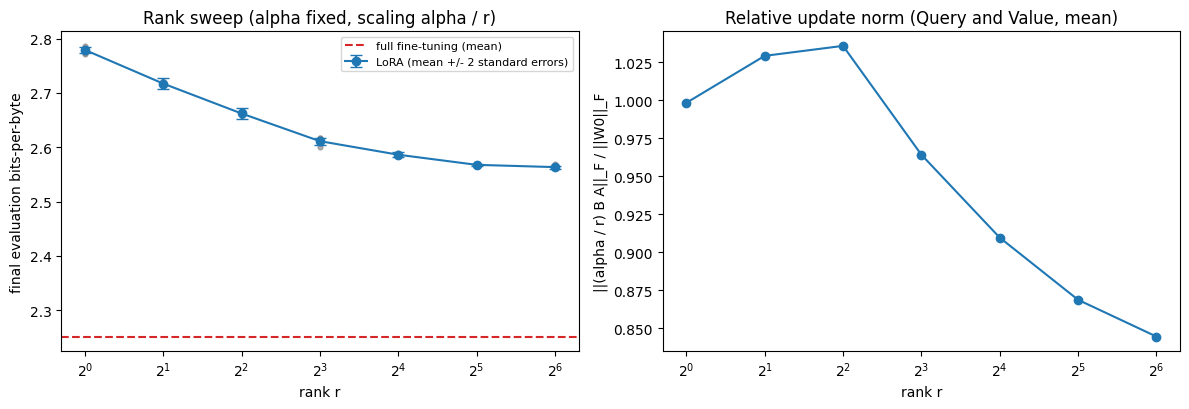

In [18]:
rank_summary = {
    r: dict(zip(("mean", "sigma"), seed_mean_and_standard_error(rs), strict=True))
    for r, rs in rank_records.items()
}
c_C = rank_summary[1]["mean"] - 2 * rank_summary[8]["mean"] + rank_summary[64]["mean"]
sigma_c_C = math.sqrt(
    rank_summary[1]["sigma"] ** 2
    + 4 * rank_summary[8]["sigma"] ** 2
    + rank_summary[64]["sigma"] ** 2
)
verdict_C = three_way_verdict(c_C, sigma_c_C)
precondition_status["C1"] = all(train_loss_dropped(rs) for rs in rank_records.values())

for _r, _s in rank_summary.items():
    _update = float(np.mean([r["relative_update_norms"] for r in rank_records[_r]]))
    print(
        f"{_smoke_tag}r={_r:>2}: b={_s['mean']:.4f}(標準誤差 {_s['sigma']:.4f}、{len(rank_records[_r])} シード)、"
        f"診断量 ||(alpha/r) B A||_F / ||W0||_F の平均 = {_update:.4f}、"
        f"学習曲線の最終区間の傾き(シード平均)= {mean_final_slope(rank_records[_r]):+.6f}"
    )
print(
    f"{_smoke_tag}Delta_low = b(r=1) - b(r=8) = {rank_summary[1]['mean'] - rank_summary[8]['mean']:.4f}, "
    f"Delta_high = b(r=8) - b(r=64) = {rank_summary[8]['mean'] - rank_summary[64]['mean']:.4f}"
)
print(f"{_smoke_tag}c = {c_C:.4f}, sigma_c = {sigma_c_C:.4f}, 2 sigma_c = {2 * sigma_c_C:.4f}")
print(
    f"{_smoke_tag}前提条件 C1(全 rank の全シードで訓練損失が 5% 以上低下): {precondition_status['C1']}"
)
print(f"{_smoke_tag}判定関数の結果: {verdict_C}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
_rs = list(rank_summary)
axes[0].errorbar(
    _rs,
    [rank_summary[r]["mean"] for r in _rs],
    yerr=[
        2 * rank_summary[r]["sigma"] if math.isfinite(rank_summary[r]["sigma"]) else 0 for r in _rs
    ],
    fmt="o-",
    capsize=4,
    label="LoRA (mean +/- 2 standard errors)",
)
for _r in _rs:
    axes[0].scatter(
        [_r] * len(rank_records[_r]),
        [x["final_bits_per_byte"] for x in rank_records[_r]],
        color="tab:gray",
        s=12,
        alpha=0.6,
    )
axes[0].axhline(b1_mean, color="tab:red", linestyle="--", label="full fine-tuning (mean)")
axes[0].set_xscale("log", base=2)
axes[0].set_xlabel("rank r")
axes[0].set_ylabel("final evaluation bits-per-byte")
axes[0].set_title("Rank sweep (alpha fixed, scaling alpha / r)")
axes[0].legend(fontsize=8)
axes[1].plot(
    _rs, [np.mean([r["relative_update_norms"] for r in rank_records[x]]) for x in _rs], "o-"
)
axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("rank r")
axes[1].set_ylabel("||(alpha / r) B A||_F / ||W0||_F")
axes[1].set_title("Relative update norm (Query and Value, mean)")
fig.tight_layout()
plt.show()

### 6.10 効率の測定(判定基準を設けない)

閉形式の表(3.1 節)を計算し、実際に数えた値と一致することをアサーションで確認する。
勾配のバイト数は逆伝播後の`.grad`、AdamW の状態のバイト数は 1 回の`step()`の後に optimizer が
保持する $m$・$v$ から数える。CUDA 環境では、1 ステップのピークメモリと 1 ステップあたりの時間も測る。

In [19]:
def count_training_state_bytes(method: str) -> dict:
    model, _ = build_condition_model(method, seed=0, rank=MAIN_RANK)
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = AdamW(trainable, lr=1e-4, weight_decay=0.0)
    inputs = train_loss_windows[:2].to(device)
    logits = model(inputs)[:, :-1, :]
    loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), inputs[:, 1:].reshape(-1))
    optimizer.zero_grad()
    loss.backward()
    grad_bytes = sum(
        p.grad.numel() * p.grad.element_size() for p in model.parameters() if p.grad is not None
    )
    optimizer.step()
    state_bytes = sum(
        t.numel() * t.element_size() for t in [*optimizer._m.values(), *optimizer._v.values()]
    )
    return {
        "trainable": sum(p.numel() for p in trainable),
        "gradient_bytes": grad_bytes,
        "adamw_state_bytes": state_bytes,
    }


_closed_form = {
    "full": TOTAL_PARAMETERS,
    "lora": 2 * NUM_LAYERS * compute_lora_parameter_count(D_MODEL, D_MODEL, MAIN_RANK),
}
efficiency_table = {}
for _method, _p_train in _closed_form.items():
    _counted = count_training_state_bytes(_method)
    _row = {
        "trainable_parameters": _p_train,
        "gradient_bytes": 4 * _p_train,
        "adamw_state_bytes": 8 * _p_train,
        "total_without_activations_bytes": 4 * TOTAL_PARAMETERS + 12 * _p_train,
    }
    assert _counted["trainable"] == _row["trainable_parameters"]
    assert _counted["gradient_bytes"] == _row["gradient_bytes"]
    assert _counted["adamw_state_bytes"] == _row["adamw_state_bytes"]
    efficiency_table[_method] = _row
print("閉形式と実際に数えた値(学習可能パラメータ数・勾配・AdamW の状態のバイト数)の一致: OK")
print(
    f"{'方式':<6} | {'学習可能パラメータ数':>18} | {'勾配 (MB)':>10} | {'AdamW 状態 (MB)':>15} | "
    f"{'活性化を除く合計 (MB)':>20}"
)
for _method, _row in efficiency_table.items():
    print(
        f"{_method:<6} | {_row['trainable_parameters']:>18,} | {_row['gradient_bytes'] / 2**20:>10.3f} | "
        f"{_row['adamw_state_bytes'] / 2**20:>15.3f} | {_row['total_without_activations_bytes'] / 2**20:>20.3f}"
    )


def measure_step_memory_and_time(method: str, num_warmup: int = 3, num_measure: int = 20) -> dict:
    model, _ = build_condition_model(method, seed=0, rank=MAIN_RANK)
    optimizer = AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-5, weight_decay=0.0)
    generator = torch.Generator().manual_seed(0)

    def one_step():
        starts = torch.randint(
            0, len(train_ids) - SEQUENCE_LENGTH - 1, (BATCH_SIZE,), generator=generator
        )
        batch = torch.stack([train_ids[s : s + SEQUENCE_LENGTH + 1] for s in starts]).to(device)
        logits = model(batch[:, :-1])
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), batch[:, 1:].reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    for _ in range(num_warmup):
        one_step()
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    t0 = time.time()
    for _ in range(num_measure):
        one_step()
    torch.cuda.synchronize()
    return {
        "peak_memory_bytes": torch.cuda.max_memory_allocated(),
        "seconds_per_step": (time.time() - t0) / num_measure,
    }


if device.type == "cuda":
    measured_efficiency = {}
    for _method in ("full", "lora"):
        measured_efficiency[_method] = measure_step_memory_and_time(_method)
        torch.cuda.empty_cache()
    print(f"{'方式':<6} | {'ピークメモリ (MB)':>16} | {'1 ステップの時間 (ms)':>20}")
    for _method, _row in measured_efficiency.items():
        print(
            f"{_method:<6} | {_row['peak_memory_bytes'] / 2**20:>16.1f} | {_row['seconds_per_step'] * 1000:>20.1f}"
        )
else:
    measured_efficiency = None
    print(f"CUDA 環境ではない({device})ため、ピークメモリ・1 ステップの時間の実測をスキップした。")

閉形式と実際に数えた値(学習可能パラメータ数・勾配・AdamW の状態のバイト数)の一致: OK
方式     |         学習可能パラメータ数 |    勾配 (MB) |   AdamW 状態 (MB) |        活性化を除く合計 (MB)
full   |          5,246,208 |     20.013 |          40.025 |               80.051
lora   |             32,768 |      0.125 |           0.250 |               20.388
方式     |      ピークメモリ (MB) |       1 ステップの時間 (ms)
full   |           2273.0 |                161.8
lora   |           1995.8 |                135.1


### 6.11 出力例(定性的な観察)

同じプロンプト・同じシードで、ベースモデル・全パラメータ微調整・LoRA($r=8$)から top-p
サンプリング($p = 0.9$、temperature 1.0)で生成する。サンプリングの乱数は CPU の
`torch.Generator`で固定し、デバイスによらず同じ乱数列を使う。

In [20]:
SAMPLE_PROMPT = "ROMEO:\n"
SAMPLE_NEW_TOKENS = 80
SAMPLE_TOP_P = 0.9
SAMPLE_SEED = 0


@torch.no_grad()
def sample_top_p(model: nn.Module, prompt: str) -> str:
    model.eval()
    token_ids = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long, device=device)
    generator = torch.Generator().manual_seed(SAMPLE_SEED)
    for _ in range(SAMPLE_NEW_TOKENS):
        logits = model(token_ids[:, -SEQUENCE_LENGTH:])[:, -1, :].float().cpu()
        probs = torch.softmax(top_p_filter(logits, SAMPLE_TOP_P), dim=-1)
        next_token = torch.multinomial(probs, num_samples=1, generator=generator).to(device)
        token_ids = torch.cat([token_ids, next_token], dim=1)
    return tokenizer.decode(token_ids[0].tolist())


for _label, _model in (
    ("ベースモデル", base_model),
    ("全パラメータ微調整(seed 0)", kept_models["full"]["model"]),
    (f"LoRA r={MAIN_RANK}(seed 0)", kept_models["lora"]["model"]),
):
    print(f"===== {_label} =====")
    print(sample_top_p(_model, SAMPLE_PROMPT))
    print()

===== ベースモデル =====
ROMEO:
QOMORESZ-Co vs. DaSGZ UTON
Clayer Chiefs Joint Marines

Truce Kommendalley (2008–2011)

Miss Press
Garley Fox (Milan), historian, director of Sputtical PBS Conference
Government Tow Restes

U.S. administration
Group Order (2011–2014)
Ukrainian

===== 全パラメータ微調整(seed 0) =====
ROMEO:
'Tis he would; my judge for what should do;
But not ask how no child 'baith, I know'st,
Your households to slew his fought!

LEONTES:
I am your brother toil; I pray it,
At is good I; look on him;
This time is like mad on m

===== LoRA r=8(seed 0) =====
ROMEO:
'O:?
It, I now what should have lport whate like I no child 'IAEM:
UpruiCrect "The First sources'd afterce if she did a rural men,
Cropry upon Hehyce-bliffen,’d jow Rome;
Tadruply nothing actually", and was our textm



### 6.12 判定結果一覧

前提条件が 1 つでも不成立の実験は、判定関数の結果に関わらず「前提不成立」とする(判定不能とは
区別する)。判定関数の結果は参考として別欄に残す。

In [21]:
_experiment_preconditions = {"A": ["A1"], "B": ["B1"], "C": ["C1"]}


def final_verdict(name: str, computed: str) -> str:
    if not all(precondition_status.get(n) for n in _experiment_preconditions[name]):
        return "前提不成立"
    return computed


_verdicts = [
    ("A", f"rho={rho:.4f}, sigma_rho={sigma_rho:.4f}, delta={DELTA_A}", verdict_A),
    ("B", f"d={d_B:.4f}, sigma_d={sigma_d_B:.4f}", verdict_B),
    ("C", f"c={c_C:.4f}, sigma_c={sigma_c_C:.4f}", verdict_C),
]
print("実験 | 対比量 | 前提条件の成否 | 判定関数の結果(参考) | 最終判定")
for _name, _stat, _computed in _verdicts:
    _pre = ", ".join(
        f"{n}={'成立' if precondition_status.get(n) else '不成立'}"
        for n in _experiment_preconditions[_name]
    )
    print(f"  {_name}: {_stat} | {_pre} | {_computed} | {final_verdict(_name, _computed)}")
print(f"\n前提条件・採用条件の成否一覧: {precondition_status}")
if SMOKE_TEST:
    print(
        "上記はスモークテスト(SMOKE_TEST=True)によるコードの動作確認結果であり、本番実行"
        "(SMOKE_TEST=False、Google Colab T4)後に数値が変わるため、結論としては扱わない。"
    )

実験 | 対比量 | 前提条件の成否 | 判定関数の結果(参考) | 最終判定
  A: rho=0.6848, sigma_rho=0.0041, delta=0.9 | A1=成立 | 反証 | 反証
  B: d=0.0279, sigma_d=0.0059 | B1=成立 | 支持 | 支持
  C: c=0.1202, sigma_c=0.0071 | C1=成立 | 支持 | 支持

前提条件・採用条件の成否一覧: {'calibration_interior_full': True, 'calibration_interior_lora': True, 'calibration_interior_sparse': True, 'A1': True, 'B1': True, 'C1': True}


## 7. 結果・考察 / Results and Discussion

本番実行(Google Colab T4、torch 2.13.0+cu130、`SMOKE_TEST=False`)のセル出力に基づいて記す。
判定は 6.1 節で事前に宣言した基準のみから導く。結果を見た後に立てた解釈は「事後的な解釈」として
節または段落を分けて記し、検証済みの結論としては扱わない。

### 7.1 較正結果

較正はすべて本番と同じ 87 ステップ・シード 0・gradient clipping なしで行った(6.3 節)。

| 方式 | 学習率: 較正用検証集合の最終 bits-per-byte | 採用した学習率 | gradient clipping の閾値 | 本番での発動率(5 シードの範囲) |
|---|---|---|---|---|
| 全パラメータ微調整 | $10^{-3.5}$: 2.3148 / $10^{-3}$: 2.1481 / $10^{-2.5}$: **2.0548** / $10^{-2}$: 2.1382 / $10^{-1.5}$: 2.9292 | $10^{-2.5}$ | 0.9471 | 0.10〜0.13 |
| LoRA($r=8$) | $10^{-2.5}$: 2.7779 / $10^{-2}$: 2.6410 / $10^{-1.5}$: **2.5648** / $10^{-1}$: 3.3538 / $10^{-0.5}$: 3.6256 | $10^{-1.5}$ | 0.2861 | 0.10〜0.20 |
| ランダムマスク疎微調整 | $10^{-2}$: 2.6999 / $10^{-1.5}$: 2.6183 / $10^{-1}$: **2.6004** / $10^{-0.5}$: 2.6967 / $10^{0}$: 3.2072 | $10^{-1}$ | 0.1004 | 0.09〜0.13 |

3 方式とも、採用した水準はグリッドの内点であり(採用条件は成立)、グリッドの拡張は起きなかった。
採用した学習率(全パラメータ微調整 $10^{-2.5}$、LoRA $10^{-1.5}$、疎微調整 $10^{-1}$)は、6.3 節に
記録した予備掃引(ローカルの MPS)で最良だった水準と一致した。gradient clipping の閾値は、勾配ノルムが
学習可能なパラメータのみから計算されるため方式ごとに大きく異なる。本番の学習での発動率は、
おおむね 0.1〜0.2 であった。

### 7.2 前提条件の成否

宣言したすべての前提条件が成立した。7.3〜7.5 節の判定に「前提不成立」の実験はない。

| 前提条件 | 評価に使った量 | 閾値 | 成否 |
|---|---|---|---|
| A1 | $b_0 - \bar{b}_1 = 1.1412$ | $10\,\sigma_{\bar{b}_1} = 10 \times 0.0051 = 0.051$ | 成立 |
| B1 | 最終訓練損失 / 学習開始時の訓練損失(LoRA・疎微調整の全シードの最大値)= 約 0.75 | 0.95 以下 | 成立 |
| C1 | 同じ比(全 rank の全シードの最大値、$r = 1$)= 約 0.82 | 0.95 以下 | 成立 |

学習開始時の訓練損失(ベースモデル、固定の訓練窓)は 6.2466 nats / トークンで、全条件で共通である。

### 7.3 実験 A(全パラメータ微調整との比較)の判定結果

**判定: 反証。**

| 条件 | 評価集合の最終 bits-per-byte(シード 0〜4) | シード平均 | 標準誤差 |
|---|---|---|---|
| $b_0$(ベースモデル) | 3.3928(決定的) | 3.3928 | 0 |
| $b_1$(全パラメータ微調整) | 2.2618・2.2410・2.2610・2.2377・2.2566 | 2.2516 | 0.0051 |
| $b_2$(LoRA、$r=8$) | 2.6077・2.6179・2.6007・2.6163・2.6138 | 2.6113 | 0.0032 |

$$
\rho = \frac{3.3928 - 2.6113}{3.3928 - 2.2516} = 0.685, \qquad \sigma_\rho = 0.004, \qquad
\rho + 2\sigma_\rho = 0.693 < \delta = 0.9
$$

$\rho + 2\sigma_\rho < \delta$ なので、事前に宣言した基準により **反証** となる。診断量として求めた
ブートストラップの 95% 区間は $[0.678, 0.692]$ であり、これも $\delta$ を大きく下回る。

**まとめ**: $T = 87$ ステップの固定の学習予算のもとで、Query・Value への LoRA($r=8$)は、
全パラメータ微調整による bits-per-byte の改善幅の約 7 割を回復したが、9 割には届かなかった。

**診断量の読み取り**:

- **学習曲線の最終区間の傾き $g$**: 全パラメータ微調整 $-3.08 \times 10^{-4}$、LoRA
  $-1.78 \times 10^{-4}$、疎微調整 $-1.45 \times 10^{-4}$(bits-per-byte / ステップ、シード平均)で、
  全方式で負だった。最終ステップの時点で、どの方式もまだ改善していた。ただし、最後の記録区間
  (ステップ 80 → 87)は cosine スケジュールの末尾にあたり、学習率はピークの約 3% から 1% まで
  下がっている。$g$ はこの小さな学習率での値なので、方式間の大小の比較や、ステップ数を増やした場合の
  外挿には使えない。
- **最良値 − 最終値**: 全方式・全シードで 0 だった。記録点の中で最終ステップが常に最良であり、
  評価集合での過学習は観測されなかった。
- **$\lVert \Delta W \rVert_F / \lVert W_0 \rVert_F$(Query・Value の 8 行列)**: LoRA は 0.59〜1.24、
  全パラメータ微調整は 0.16〜0.28 であった。Query・Value の重みの変化は、LoRA のほうが大きい。
- **全パラメータ微調整の $\Delta W$ の上位 8 特異値のエネルギー割合**: 0.29〜0.41 であった。
  256 個の特異値が均等にエネルギーを持つ場合の $8 / 256 \approx 0.031$ に比べれば上位の方向に
  集中しているが、エネルギーの 59〜71% は上位 8 方向の外にある。同じ形のランダム行列での参照値は
  計算していないため、ランダムな更新との比較はここでは行わない。

#### 7.3.1 事後的な解釈(事前宣言した判定とは独立)

**この小節は、結果を見た後に立てた事後的な解釈であり、検証済みの結論ではない。** 7.3 節の判定
(反証)はこの小節の内容によって変わらない。

実験 C の数値(7.5 節)から同じ式で回復率を計算すると、$r = 64$ でも
$(3.3928 - 2.5635) / (3.3928 - 2.2516) \approx 0.73$ にとどまる($r = 1$ で約 0.54、$r = 8$ で
0.685)。$d_{\mathrm{model}} = 256$ に対して rank 64 の制約は緩いので、全パラメータ微調整との差の
大部分は rank の制約ではなく、適応させる対象を Query・Value に限ったことに由来する可能性がある。
全パラメータ微調整は、Query・Value に加えて、Key・出力の射影、埋め込み(出力層と重みを共有)、
順伝播ネットワーク(Feed-Forward Network)、正規化層も更新している。

これは事前に宣言した量ではなく、本トピックでは検証していない仮説である。LoRA の適用対象を広げた
比較(例えば順伝播ネットワークや出力層にも掛ける)によって確かめうる。LoRA を使う後続のトピック
([016](../04_alignment/016_supervised_fine_tuning.ipynb) など)で扱える。

3.8 節では、小規模かつドメイン差が大きい設定では LoRA が全パラメータ微調整に届かない可能性がある
(Biderman et al. 2024 [6])と事前に注記した。今回の反証はこの注記と矛盾しない。ただし、
Biderman et al. が扱ったのは大規模なデータでの継続事前学習・指示チューニングであり、本トピックの
設定(小型モデル、87 ステップ)とは規模が大きく異なる。同論文が指摘する「全パラメータ微調整の
更新量は高い rank を持つ」ことと、上記のエネルギー割合の診断量(上位 8 方向の外にエネルギーの
6〜7 割がある)は同じ方向を示しているが、ランダム行列の参照値がないため、この対応も検証済みでは
ない。

### 7.4 実験 B(同じパラメータ数の対照との比較)の判定結果

**判定: 支持。**

| 条件 | 評価集合の最終 bits-per-byte(シード 0〜4) | シード平均 | 標準誤差 |
|---|---|---|---|
| $b_2$(LoRA、$r=8$) | 2.6077・2.6179・2.6007・2.6163・2.6138 | 2.6113 | 0.0032 |
| $b_3$(ランダムマスク疎微調整) | 2.6396・2.6362・2.6353・2.6271・2.6574 | 2.6391 | 0.0050 |

$$
d = \bar{b}_3 - \bar{b}_2 = 0.028, \qquad \sigma_d = 0.006, \qquad 2\sigma_d = 0.012
$$

$d > 2\sigma_d$ なので、事前に宣言した基準により **支持** となる。$T = 87$ ステップの固定の学習予算の
もとで、学習可能パラメータ数を揃えたとき、低ランク構造の更新(LoRA)のほうが、ランダムに選んだ
要素だけを更新する疎な微調整よりも、評価集合の bits-per-byte が低かった。

**診断量の読み取り**:

- **最終訓練損失の差(疎微調整 − LoRA)**: $-0.009$ nats / トークン(疎微調整 4.6563、LoRA 4.6656)。
  シードごとの値は、LoRA が 4.6437〜4.6821(標本標準偏差 0.016)、疎微調整が 4.6505〜4.6676
  (同 0.007)で、2 方式の範囲は重なっている。差の標準誤差は約 0.008 であり、差はシード間の
  ばらつきと同程度である。したがって、訓練データへの当てはまりは 2 方式で同程度であり、評価集合で
  のみ LoRA が良かった。差は最適化のしやすさではなく、汎化の側に現れていると読める。なお、訓練損失は
  nats / トークン、判定に使った量は bits-per-byte であり、単位が異なるので、2 つの差の大きさを
  直接比べることはできない。
- **学習曲線の最終区間の傾き $g$**: LoRA $-1.78 \times 10^{-4}$、疎微調整 $-1.45 \times 10^{-4}$
  (bits-per-byte / ステップ)で、どちらも最終ステップの時点でまだ改善していた。7.3 節と同じ理由
  (最後の区間の学習率がピークの約 1〜3%)により、この値から方式間の収束の度合いの違いは読み取らない。
- **疎微調整の $\lVert \Delta W \rVert_F / \lVert W_0 \rVert_F$**: 1.08〜2.12 であった。学習可能な
  要素は各行列の 6.25% のみなので、少数の要素に大きな更新が集中している。

学習曲線の途中では、2 方式の大小が最終ステップと逆だった区間がある(7.8 節)。

### 7.5 実験 C(rank の飽和)の判定結果

**判定: 支持。**

| rank $r$ | シード数 | $\bar{b}_r$ | 標準誤差 | 次の rank(2 倍)への改善幅 | $\lVert \frac{\alpha}{r} B A \rVert_F / \lVert W_0 \rVert_F$ | 最終区間の傾き $g$ |
|---|---|---|---|---|---|---|
| 1 | 5 | 2.7792 | 0.0030 | 0.062 | 0.998 | $-1.86 \times 10^{-4}$ |
| 2 | 2 | 2.7172 | 0.0053 | 0.055 | 1.029 | $-1.85 \times 10^{-4}$ |
| 4 | 2 | 2.6622 | 0.0054 | 0.051 | 1.036 | $-1.12 \times 10^{-4}$ |
| 8 | 5 | 2.6113 | 0.0032 | 0.025 | 0.964 | $-1.78 \times 10^{-4}$ |
| 16 | 2 | 2.5863 | 0.0025 | 0.019 | 0.910 | $-1.71 \times 10^{-4}$ |
| 32 | 2 | 2.5677 | 0.0009 | 0.004 | 0.869 | $-2.04 \times 10^{-4}$ |
| 64 | 5 | 2.5635 | 0.0014 | - | 0.844 | $-1.60 \times 10^{-4}$ |

$$
\Delta_{\mathrm{low}} = 2.7792 - 2.6113 = 0.168, \qquad
\Delta_{\mathrm{high}} = 2.6113 - 2.5635 = 0.048
$$

$$
c = \Delta_{\mathrm{low}} - \Delta_{\mathrm{high}} = 0.120, \qquad \sigma_c = 0.007, \qquad 2\sigma_c = 0.014
$$

$c > 2\sigma_c$ なので、事前に宣言した基準により **支持** となる。rank を 1 → 8 に上げたときの改善幅は、
8 → 64 に上げたときの改善幅の約 3.5 倍だった。

**診断量と交絡**:

- rank を 2 倍にするごとの改善幅は、0.062 → 0.055 → 0.051 と推移した後、$r = 8$ を境に
  0.025 → 0.019 → 0.004 と小さくなった。中間の rank(2・4・16・32)は 2 シードなので、この推移は
  判定に使わない記述である。$\Delta_{\mathrm{high}}$ も正であり、$r = 8$ 以降も改善は続いている。
  したがって、rank の効果は「頭打ち」ではなく **「逓減」** と書くのが正確である。
- 更新量の比 $\lVert \frac{\alpha}{r} B A \rVert_F / \lVert W_0 \rVert_F$ は、$r = 1$ の約 1.00 から
  $r = 64$ の約 0.84 へ、約 15% 縮んだ。単調ではなく、$r = 4$(約 1.04)を最大として、それより大きい
  rank で縮んでいる。rsLoRA が指摘する $\alpha / r$ による更新量の縮小は観測されたが、その程度は穏やか
  であった。
- rank ごとの最終区間の傾き $g$ は $-1.1 \times 10^{-4}$〜$-2.0 \times 10^{-4}$ で、rank に対する
  一貫した傾向はなかった。ただし 7.3 節と同じ理由(最後の区間の学習率が小さい)により、$g$ は
  「大きい rank ほど収束から遠い」かどうかの強い手がかりにはならない。
- 6.1 節で宣言したとおり、**支持の判定は「低ランクで十分である」ことの検証とはみなさない。**
  更新量の縮小は穏やかだったとはいえ存在しており、この実験だけでは、改善の逓減の原因が低ランク性
  (小さい rank で必要な更新を表現しきれている)なのか、大きい rank での更新量の縮小なのかを
  区別できない。

### 7.6 効率の測定

判定基準を設けない測定である(6.1 節)。

**閉形式(活性化を除く、3.1 節)**:

| 方式 | 学習可能パラメータ数 | 勾配 | AdamW の状態 | 活性化を除く合計 |
|---|---|---|---|---|
| 全パラメータ微調整 | 5,246,208 | 20.0 MB | 40.0 MB | 80.1 MB |
| LoRA($r=8$) | 32,768 | 0.125 MB | 0.250 MB | 20.4 MB |

閉形式の値は、実際のパラメータ・勾配・AdamW の状態から数えた値と一致した(アサーションで確認)。
閉形式による削減は約 60 MB である。

**T4 での実測(バッチサイズ 32、系列長 256、1 ステップ)**:

| 方式 | ピークメモリ | 1 ステップの時間 |
|---|---|---|
| 全パラメータ微調整 | 2273.0 MB | 161.8 ms |
| LoRA($r=8$) | 1995.8 MB | 135.1 ms |

ピークメモリの削減は 277 MB で、閉形式による削減(約 60 MB)を大きく上回った。これは 3.1 節で述べた
仕組みと整合する。LoRA の条件では、重みを凍結した線形層のうち、出力の射影・順伝播ネットワークの
3 つの射影・出力層(埋め込みと重みを共有)は、逆伝播のために入力を保存する必要がなく、活性化の
メモリも一部減る。これらの入力(注意の重み付き和を連結したもの、正規化層の出力、SwiGLU のゲートとの
積、最終正規化層の出力)は、モデルの構造上、ほかの学習可能な層や非線形の演算には保存されない。
一方、Key の射影は凍結していてもこの例に含まれない。Key の射影は Query・Value の射影と同じ入力
テンソル(正規化層の出力)を受け取り、学習可能な LoRA の $A$ がその入力を保存するからである。
入力を共有する層のうち 1 つでも学習可能であれば、その入力の保存は残る。ただし、
本ノートブックでは保存テンソルの内訳を測っていないので、277 MB のうちどれだけがこの仕組みによるかは
分解していない。1 ステップの時間が約 16.5% 短くなったことも、凍結した線形層で重みの勾配の行列積を
省けるという 3.1 節の説明と整合する。

一方、ピークメモリの総量に対する削減率は約 12% にとどまった。学習可能パラメータ数は約 160 分の 1
になったが、LoRA の条件でも重み・勾配・AdamW の状態の合計は閉形式で 20.4 MB にすぎず、約 2 GB の
ピークメモリの大部分は活性化などの、パラメータ以外のメモリが占めている(その内訳は測っていない)。
活性化のメモリが支配的であるという、011 の実験 G で見た構図と整合する。

### 7.7 出力例

同じプロンプト(`ROMEO:`)・同じシードでの top-p サンプリングの生成例(6.11 節)を比べると、次の違いが
見られた。

- **ベースモデル**: 記事の見出しや年号の範囲(「(2008–2011)」など)が並び、英語版 Wikipedia 風の
  文を生成している。
- **全パラメータ微調整**: 話者名(`LEONTES:`)・台詞ごとの改行・古語風の語彙(`'Tis`、`know'st`)
  など、戯曲の形式をおおむね再現している。
- **LoRA($r=8$)**: 戯曲の書き出しを部分的に再現するが、途中で崩れ、Wikipedia 風の断片
  (`The First sources`、`rural men`、`actually`など)が混じる。

この違いは、LoRA が全パラメータ微調整の改善幅の約 7 割しか回復しなかった実験 A の結果と定性的に
整合する。ただし各条件 1 サンプルのみの観察であり、判定の根拠ではない。

### 7.8 可視化

**図: 評価集合の学習曲線と最終 bits-per-byte の散布図(6.7 節)**

- 全パラメータ微調整は、最初の記録点(ステップ 10)の時点で bits-per-byte を約 2.55 まで下げており、
  LoRA・疎微調整(約 2.8〜2.95)より立ち上がりが大きく速い。以降は 3 方式ともゆるやかに下がり続け、
  最終ステップまで改善が続く(7.3 節の $g$ と整合)。
- LoRA と疎微調整の学習曲線は交差している。図から読み取る限り、ステップ 10〜20 では疎微調整の
  ほうが低く、ステップ 30 前後で並び、それ以降は LoRA のほうが低い。学習曲線の途中の値はセル出力に
  数値として印字していないため、交差の位置は図からの読み取りである。
- 散布図では、3 方式の最終値のシード間のばらつきは方式間の差に比べて小さく、方式どうしの範囲は
  重ならない。

**図: rank の掃引と更新量の比(6.9 節)**

- 最終 bits-per-byte は rank とともに単調に下がり、$r = 8$ 以降は傾きが小さくなる(7.5 節の逓減)。
  すべての rank で、全パラメータ微調整の平均(破線)から大きく離れている。
- 更新量の比は $r = 4$ で最大となり、それより大きい rank で縮む(7.5 節)。

**事後的な解釈(学習曲線の交差について)**: 以下は結果を見た後の解釈であり、7.4 節の判定(支持)を
変えるものではない。LoRA と疎微調整の大小が学習の途中で入れ替わっていることから、実験 B の結論は
学習予算 $T$ に依存しうる。事前に宣言した $T = 87$ のもとでは LoRA が良かったが、より少ないステップ数
では逆の結論になりえた。6.1 節で明記したとおり、実験 B の判定は固定の学習予算のもとでの比較である。
LoRA の立ち上がりが遅いことについては、最初のステップで $A$ が更新されないこと(3.3 節)だけでは、
ステップ 10〜20 まで続く差を説明できない。考えられる説明は、更新量が積 $\frac{\alpha}{r} B A$ で
表され、$B = 0$ から始まるため、学習の初期は $\Delta W$ の実効的な変化の速さが小さく、$B$ が 0 から
離れるにつれて大きくなる、というものである。これも検証していない説明である。

### 7.9 全体としての考察

**判定の一覧**(前提条件はすべて成立、7.2 節):

| 実験 | 検証したこと | 判定 |
|---|---|---|
| A | Query・Value への LoRA($r=8$)が全パラメータ微調整の改善幅の 9 割以上を回復する | 反証($\rho = 0.685$) |
| B | 同じパラメータ数なら、低ランク構造の更新がランダムな疎な更新より評価集合で良い | 支持($d = 0.028$) |
| C | rank 1 → 8 の改善幅が 8 → 64 の改善幅より大きい | 支持($c = 0.120$) |

**言えること**(いずれも $T = 87$ ステップの固定の学習予算のもとで):

- Query・Value への LoRA($r=8$、学習可能パラメータは全体の 0.62%)は、全パラメータ微調整の
  改善幅の約 7 割を回復する。9 割には届かない。
- 学習可能パラメータ数を揃えると、低ランク構造の更新はランダムな疎な更新より評価集合の
  bits-per-byte が低い。訓練損失は同程度であり、差は汎化の側に現れている(診断量の読み取り)。
- rank を上げたときの改善効果は、$r = 8$ 付近から逓減する。

**言えないこと**:

- 各方式が収束した状態での比較。全方式が最終ステップの時点でまだ改善しており、判定は固定の学習予算の
  もとでの比較である。
- 「低ランクで十分である」こと。実験 C の支持は、rsLoRA が指摘する更新量の縮小という交絡を分離
  していない。
- 実験 A の差の原因が、適応させる対象を Query・Value に限ったことにある、ということ(7.3.1 節の
  事後的な仮説)。

**今後確かめるべきこと**(事後的に立てた仮説であり、本トピックの結論ではない):

- LoRA の適用対象を Query・Value 以外(順伝播ネットワーク・出力層など)に広げると、実験 A の回復率が
  どこまで上がるか(7.3.1 節)。
- 実験 B の結論が学習予算 $T$ にどう依存するか(7.8 節の学習曲線の交差)。
- rank の効果の逓減のうち、低ランク性によるものと更新量の縮小によるものを分けること(例えば
  rsLoRA の $\alpha / \sqrt{r}$ スケーリングで同じ掃引を行う)。